=== From your R(beta) data (scale-units) ===
beta    R(beta)      C_eff = c0/(beta*R^2)
 0.4   0.24488281   5.211148
 0.8   0.14542969   7.387779
 1.2   0.10386719   9.655439
 1.6   0.08160156   11.732568
 2.0   0.06824219   13.420668
 2.4   0.05785156   15.562114
 2.8   0.05117188   17.048624
 3.2   0.04597656   18.479365

C_fit (avg over beta>=2.0) = 16.127693

=== Scale->r_infty conversion (Gaussian sampling diagnostic) ===
k = E[r_infty/r_rms] ≈ 5.8030 ± 0.2695  (L=8)
Implied C_infty ≈ C_fit / k^2 ≈ 0.478918

FLOW ENVELOPE TEST
L=8, beta=3.0, init_scale=0.15, c0=0.125, dt=0.005
Using C_fit(scale)=16.1277 and C_infty(r_infty)=0.4789


/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


t=0.000  λ_min=-0.350227 [UNSTABLE]  r_rms=0.14945  r_inf=0.84298  env_rms=-0.955705  env_inf=-0.895978  C_rms=7.092  C_inf=0.223
t=0.010  λ_min=-0.325274 [UNSTABLE]  r_rms=0.14509  r_inf=0.81686  env_rms=-0.893490  env_inf=-0.833694  C_rms=7.130  C_inf=0.225
t=0.020  λ_min=-0.296317 [UNSTABLE]  r_rms=0.14096  r_inf=0.79186  env_rms=-0.836294  env_inf=-0.775905  C_rms=7.068  C_inf=0.224
t=0.030  λ_min=-0.272501 [UNSTABLE]  r_rms=0.13705  r_inf=0.76793  env_rms=-0.783705  env_inf=-0.722285  C_rms=7.055  C_inf=0.225
t=0.040  λ_min=-0.254409 [UNSTABLE]  r_rms=0.13335  r_inf=0.74504  env_rms=-0.735341  env_inf=-0.672526  C_rms=7.112  C_inf=0.228
t=0.050  λ_min=-0.229862 [UNSTABLE]  r_rms=0.12985  r_inf=0.72315  env_rms=-0.690849  env_inf=-0.626342  C_rms=7.015  C_inf=0.226
t=0.060  λ_min=-0.214180 [UNSTABLE]  r_rms=0.12655  r_inf=0.70221  env_rms=-0.649906  env_inf=-0.583465  C_rms=7.059  C_inf=0.229
t=0.070  λ_min=-0.198137 [UNSTABLE]  r_rms=0.12344  r_inf=0.68219  env_rms=-0.612215  env_

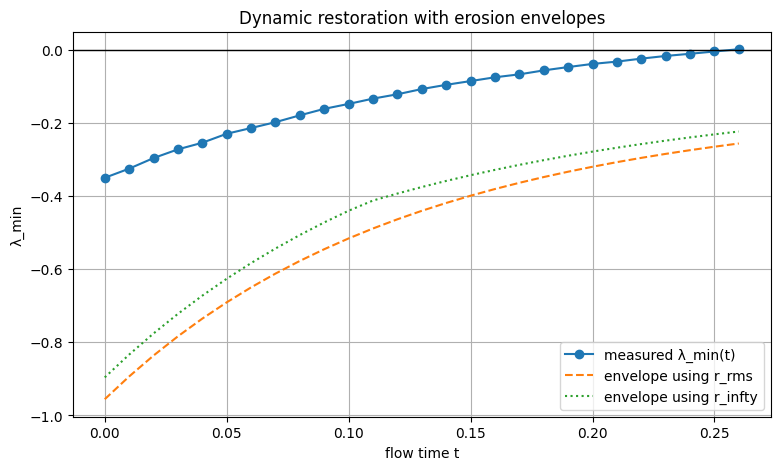

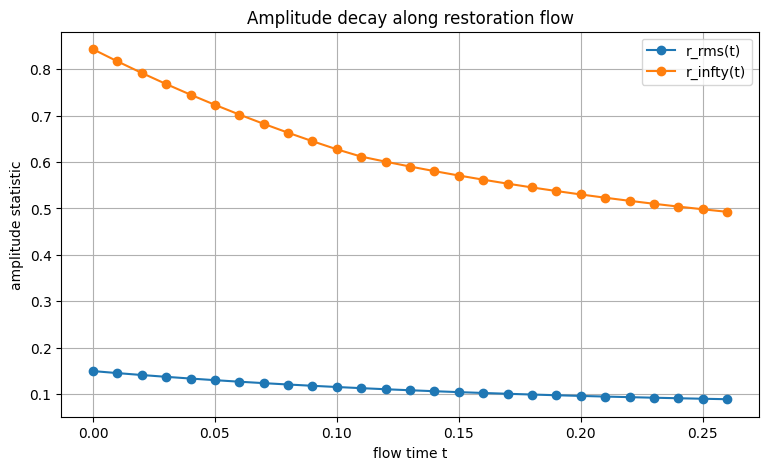

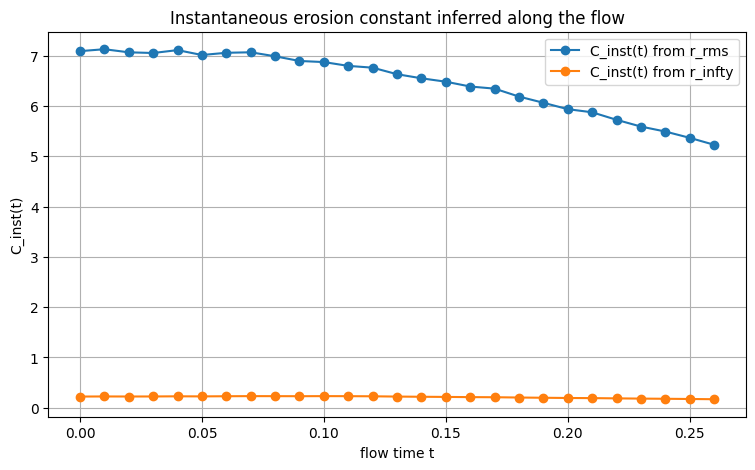

In [ ]:
# ============================================================
# YANG-MILLS NEXT STEP: LOG r_t AND TEST λ_min ≈ c0 - C β r_t^2
# (SU(3) exponential chart, Wilson + quadratic Haar, Lanczos HVP)
# Paste into a fresh Colab cell (GPU runtime recommended).
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.lax as lax
from functools import partial

jax.config.update("jax_enable_x64", False)

# -------------------------
# 1) SU(3) basis + fast exp
# -------------------------
def su3_generators():
    lam1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]], jnp.complex64)
    lam2 = jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]], jnp.complex64)
    lam3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]], jnp.complex64)
    lam4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]], jnp.complex64)
    lam5 = jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]], jnp.complex64)
    lam6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]], jnp.complex64)
    lam7 = jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]], jnp.complex64)
    lam8 = jnp.array([[1,0,0],[0,1,0],[0,0,-2]], jnp.complex64) / jnp.sqrt(3)
    # anti-Hermitian generators T_a = i λ_a / 2
    return 1j * jnp.stack([lam1,lam2,lam3,lam4,lam5,lam6,lam7,lam8], 0) / 2.0

T_SU3 = su3_generators()

def su3_alg_from_vec(a):
    # a: (..., 8) -> A: (...,3,3) in su(3)
    return jnp.einsum("...a,aij->...ij", a, T_SU3)

@jax.checkpoint
def su3_exp_pade22(A):
    # [2/2] Padé for exp(A): good for small A, fast.
    I = jnp.eye(3, dtype=jnp.complex64)
    A2 = A @ A
    c1, c2 = 0.5, 0.083333336  # 1/2, 1/12
    Num = I + c1*A + c2*A2
    Den = I - c1*A + c2*A2
    return jnp.linalg.solve(Den, Num)

def build_links_factory(L):
    @jax.checkpoint
    def build_links(params):
        # params: (L,L,L,L,4,8) -> U: (L,L,L,L,4,3,3)
        flat = params.reshape(-1, 8)
        A = jax.vmap(su3_alg_from_vec)(flat)
        U = jax.vmap(su3_exp_pade22)(A)
        return U.reshape(L, L, L, L, 4, 3, 3)
    return build_links

# -------------------------
# 2) Wilson action (4D) + quadratic Haar mass
# -------------------------
@jax.jit
def compute_plaquette_sum(U, beta):
    # U: (L,L,L,L,4,3,3)
    S = 0.0
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :, :]
            U_nu_shift = jnp.roll(U[..., nu, :, :], -1, axis=mu)
            U_mu_dag_shift = jnp.swapaxes(
                jnp.conjugate(jnp.roll(U[..., mu, :, :], -1, axis=nu)), -1, -2
            )
            U_nu_dag = jnp.swapaxes(jnp.conjugate(U[..., nu, :, :]), -1, -2)
            P = U_mu @ U_nu_shift @ U_mu_dag_shift @ U_nu_dag
            trP = jnp.real(jnp.einsum("...ii->...", P))
            S += jnp.sum(1.0 - trP / 3.0)
    return beta * S

def wilson_action(params, L, beta, build_links_L):
    U = build_links_L(params)
    return compute_plaquette_sum(U, beta)

@jax.jit
def haar_mass_quadratic(params, c0):
    # With T_a = i λ_a / 2 and tr(λ_a λ_b)=2δ_ab, one has tr(A†A)=0.5||a||^2.
    # So Haar quadratic ~ c0 * sum_links tr(A†A) = 0.5*c0*sum(params^2).
    return 0.5 * c0 * jnp.sum(params * params)

def make_flat_funcs(L, beta, c0):
    build_links_L = build_links_factory(L)
    def unflatten(theta): return theta.reshape((L, L, L, L, 4, 8))

    @jax.jit
    def flat_action(theta):
        params = unflatten(theta)
        return wilson_action(params, L, beta, build_links_L) + haar_mass_quadratic(params, c0)

    return flat_action, unflatten

# -------------------------
# 3) HVP + Lanczos λ_min
# -------------------------
def make_grad_and_hvp(flat_action):
    grad_fun = jax.jit(jax.grad(flat_action))

    @jax.jit
    def hvp(theta, v):
        # Hessian-vector product via jvp(grad)
        _, hv = jax.jvp(grad_fun, (theta,), (v,))
        return hv

    return grad_fun, hvp

def lanczos_min(hvp_fun, theta, k=25, seed=0):
    key = jax.random.PRNGKey(seed)
    n = theta.shape[0]
    v0 = jax.random.normal(key, (n,), dtype=jnp.float32)
    v0 = v0 / (jnp.linalg.norm(v0) + 1e-9)

    def step(carry, _):
        v_prev, v, beta_prev = carry
        w = hvp_fun(theta, v)
        w = w - beta_prev * v_prev
        alpha = jnp.dot(w, v)
        w = w - alpha * v
        beta = jnp.linalg.norm(w)
        v_next = w / (beta + 1e-9)
        return (v, v_next, beta), (alpha, beta)

    (_, _, _), (alphas, betas) = lax.scan(
        step,
        init=(jnp.zeros_like(v0), v0, 0.0),
        xs=None,
        length=k
    )

    alphas = jnp.array(alphas)
    betas  = jnp.array(betas[:-1])
    T = jnp.diag(alphas) + jnp.diag(betas, 1) + jnp.diag(betas, -1)
    return float(jnp.linalg.eigvalsh(T)[0])

# -------------------------
# 4) Gradient flow step
# -------------------------
@partial(jax.jit, static_argnums=(1,))
def flow_step(theta, grad_fun, dt):
    return theta - dt * grad_fun(theta)

# -------------------------
# 5) Amplitude statistics r_rms and r_infty
# -------------------------
@jax.jit
def r_rms(theta):
    return jnp.sqrt(jnp.mean(theta * theta) + 1e-12)

@jax.jit
def r_infty(theta):
    a = theta.reshape(-1, 8)
    norms = jnp.sqrt(jnp.sum(a * a, axis=1) + 1e-12)
    return jnp.max(norms)

def estimate_infty_over_rms_ratio(L, scale=0.05, n=16, seed=0):
    key = jax.random.PRNGKey(seed)
    ratios = []
    for i in range(n):
        key, sub = jax.random.split(key)
        theta = (scale * jax.random.normal(sub, (L,L,L,L,4,8), dtype=jnp.float32)).reshape(-1)
        ratios.append(float(r_infty(theta) / r_rms(theta)))
    return float(np.mean(ratios)), float(np.std(ratios))

# -------------------------
# 6) Your measured R(beta) curve (L=8) and C_fit in "r_rms ~ scale" units
# -------------------------
c0 = 0.125
R_curve = [
    (0.4, 0.24488281250000005),
    (0.8, 0.14542968750000002),
    (1.2000000000000002, 0.1038671875),
    (1.6, 0.0816015625),
    (2.0, 0.0682421875),
    (2.4, 0.05785156250000001),
    (2.8000000000000003, 0.051171875000000006),
    (3.2, 0.045976562500000005),
]
betas = np.array([b for b,_ in R_curve], dtype=float)
Rs    = np.array([r for _,r in R_curve], dtype=float)

Ceff = c0 / (betas * Rs**2)
mask = betas >= 2.0
C_fit = float(Ceff[mask].mean())

print("=== From your R(beta) data (scale-units) ===")
print("beta    R(beta)      C_eff = c0/(beta*R^2)")
for b,r,ce in zip(betas, Rs, Ceff):
    print(f"{b:4.1f}   {r:0.8f}   {ce:0.6f}")
print(f"\nC_fit (avg over beta>=2.0) = {C_fit:.6f}")

# Convert to an r_infty-constant using the measured ratio k = r_infty / r_rms.
L_for_ratio = 8
k_mean, k_std = estimate_infty_over_rms_ratio(L_for_ratio, scale=0.05, n=16, seed=7)
C_infty = C_fit / (k_mean**2)

print("\n=== Scale->r_infty conversion (Gaussian sampling diagnostic) ===")
print(f"k = E[r_infty/r_rms] ≈ {k_mean:.4f} ± {k_std:.4f}  (L={L_for_ratio})")
print(f"Implied C_infty ≈ C_fit / k^2 ≈ {C_infty:.6f}")

# -------------------------
# 7) FLOW LOGGER: log (t, λ_min, r_rms, r_infty) and test envelopes
# -------------------------
def run_flow_envelope_test(
    L=8,
    beta=3.0,
    init_scale=0.15,
    c0=0.125,
    C_fit=C_fit,
    C_infty=C_infty,
    dt=0.005,
    max_steps=80,
    measure_every=2,
    lanczos_k=25,
    seed_theta=101,
    seed_lanczos=0,
):
    print("\n============================================================")
    print("FLOW ENVELOPE TEST")
    print(f"L={L}, beta={beta}, init_scale={init_scale}, c0={c0}, dt={dt}")
    print(f"Using C_fit(scale)={C_fit:.4f} and C_infty(r_infty)={C_infty:.4f}")
    print("============================================================")

    flat_action, _ = make_flat_funcs(L, beta, c0)
    grad_fun, hvp_fun = make_grad_and_hvp(flat_action)

    key = jax.random.PRNGKey(seed_theta)
    theta = (init_scale * jax.random.normal(key, (L,L,L,L,4,8), dtype=jnp.float32)).reshape(-1)

    logs = []
    t0 = time.time()

    for i in range(max_steps + 1):
        if i % measure_every == 0:
            t = i * dt
            lam = lanczos_min(hvp_fun, theta, k=lanczos_k, seed=seed_lanczos + i)
            rr  = float(r_rms(theta))
            ri  = float(r_infty(theta))

            # Envelopes
            lam_env_rms   = c0 - C_fit   * beta * (rr**2)
            lam_env_infty = c0 - C_infty * beta * (ri**2)

            # Instantaneous C(t) diagnostics
            C_inst_rms   = (c0 - lam) / (beta * (rr**2) + 1e-12)
            C_inst_infty = (c0 - lam) / (beta * (ri**2) + 1e-12)

            logs.append((t, lam, rr, ri, lam_env_rms, lam_env_infty, C_inst_rms, C_inst_infty))

            status = "RESTORED" if lam > 0 else "UNSTABLE"
            print(
                f"t={t:0.3f}  λ_min={lam:+.6f} [{status}]  "
                f"r_rms={rr:.5f}  r_inf={ri:.5f}  "
                f"env_rms={lam_env_rms:+.6f}  env_inf={lam_env_infty:+.6f}  "
                f"C_rms={C_inst_rms:.3f}  C_inf={C_inst_infty:.3f}"
            )

            if lam > 0:
                break

        if i < max_steps:
            theta = flow_step(theta, grad_fun, dt)

    print(f"\nTotal wall time: {time.time() - t0:.2f}s")
    return np.array(logs, dtype=float)

logs = run_flow_envelope_test(
    L=8, beta=3.0, init_scale=0.15,
    c0=c0, C_fit=C_fit, C_infty=C_infty,
    dt=0.005, max_steps=120, measure_every=2,
    lanczos_k=25, seed_theta=101, seed_lanczos=0
)

# -------------------------
# 8) Quick plots + gamma estimates
# -------------------------
t   = logs[:,0]
lam = logs[:,1]
rr  = logs[:,2]
ri  = logs[:,3]
env_rms = logs[:,4]
env_inf = logs[:,5]
Cinst_rms = logs[:,6]
Cinst_inf = logs[:,7]

# Estimate contraction rates gamma by log-linear fit over latter half of trajectory
def fit_gamma(t, r, frac_start=0.3):
    n = len(t)
    j0 = int(frac_start * n)
    tt = t[j0:]
    yy = np.log(np.maximum(r[j0:], 1e-12))
    slope, intercept = np.polyfit(tt, yy, 1)
    return float(-slope)

gamma_rms = fit_gamma(t, rr, frac_start=0.3)
gamma_inf = fit_gamma(t, ri, frac_start=0.3)

print("\n=== Rough contraction-rate estimates (log-linear fit) ===")
print(f"gamma_rms   ≈ {gamma_rms:.4f}  (from r_rms)")
print(f"gamma_infty ≈ {gamma_inf:.4f}  (from r_infty)")

plt.figure(figsize=(9,5))
plt.plot(t, lam, "o-", label="measured λ_min(t)")
plt.plot(t, env_rms, "--", label="envelope using r_rms")
plt.plot(t, env_inf, ":", label="envelope using r_infty")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("flow time t")
plt.ylabel("λ_min")
plt.title("Dynamic restoration with erosion envelopes")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(t, rr, "o-", label="r_rms(t)")
plt.plot(t, ri, "o-", label="r_infty(t)")
plt.xlabel("flow time t")
plt.ylabel("amplitude statistic")
plt.title("Amplitude decay along restoration flow")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(t, Cinst_rms, "o-", label="C_inst(t) from r_rms")
plt.plot(t, Cinst_inf, "o-", label="C_inst(t) from r_infty")
plt.xlabel("flow time t")
plt.ylabel("C_inst(t)")
plt.title("Instantaneous erosion constant inferred along the flow")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import time, math
import numpy as np
import jax
import jax.numpy as jnp

# ---------------- USER KNOBS ----------------
USE_X64        = True     # D4 is delicate; x64 is worth it here.
N_RANDOM_PROBE = 4000     # random (u,x) probes for a lower bound on the biquadratic norm
POWER_ITERS    = 80       # power iteration steps for spectral norm upper bound
SEED           = 0
# --------------------------------------------

jax.config.update("jax_enable_x64", USE_X64)
dtype_real = jnp.float64 if USE_X64 else jnp.float32
dtype_cplx = jnp.complex128 if USE_X64 else jnp.complex64

# --------- SU(3) generators: T_a = (i/2) λ_a (anti-Hermitian) ---------
def su3_generators():
    i = 1j
    zero = 0.0
    one  = 1.0
    lam1 = jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=dtype_cplx)
    lam2 = jnp.array([[0,-i,0],[i,0,0],[0,0,0]], dtype=dtype_cplx)
    lam3 = jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=dtype_cplx)
    lam4 = jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=dtype_cplx)
    lam5 = jnp.array([[0,0,-i],[0,0,0],[i,0,0]], dtype=dtype_cplx)
    lam6 = jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=dtype_cplx)
    lam7 = jnp.array([[0,0,0],[0,0,-i],[0,i,0]], dtype=dtype_cplx)
    lam8 = (1.0/jnp.sqrt(3.0))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=dtype_cplx)
    lams = [lam1,lam2,lam3,lam4,lam5,lam6,lam7,lam8]
    return jnp.stack([(0.5j)*L for L in lams], axis=0)  # (8,3,3)

T_SU3 = su3_generators()

def su3_alg_from_vec(a8):
    # a8: (8,)
    return jnp.einsum("a,aij->ij", a8.astype(dtype_real), T_SU3)

# --------- cheap exp via Pade(2,2): good enough near identity ---------
@jax.jit
def su3_exp_pade22(A):
    I = jnp.eye(3, dtype=dtype_cplx)
    A2 = A @ A
    num = I + 0.5*A + (1.0/12.0)*A2
    den = I - 0.5*A + (1.0/12.0)*A2
    return jnp.linalg.solve(den, num)

# --------- one-plaquette Wilson piece f(a0,a1,a2,a3) ---------
def plaquette_action_flat(x32):
    # x32: (32,) = concat of 4 links × 8 coords
    a = x32.reshape(4, 8).astype(dtype_real)
    A0 = su3_alg_from_vec(a[0])
    A1 = su3_alg_from_vec(a[1])
    A2 = su3_alg_from_vec(a[2])
    A3 = su3_alg_from_vec(a[3])

    U0 = su3_exp_pade22(A0)
    U1 = su3_exp_pade22(A1)
    # dagger links ~ exp(-A) since A anti-Hermitian
    U2d = su3_exp_pade22(-A2)
    U3d = su3_exp_pade22(-A3)

    Up = U0 @ U1 @ U2d @ U3d
    tr = jnp.real(jnp.trace(Up))
    return (1.0 - tr/3.0).astype(dtype_real)

# Build derivatives
hess_f = jax.hessian(plaquette_action_flat)
jac_h  = jax.jacfwd(hess_f)          # D^3 f at 0: shape (32,32,32)
jac2_h = jax.jacfwd(jac_h)           # D^4 f at 0: shape (32,32,32,32)

x0 = jnp.zeros((32,), dtype=dtype_real)

t0 = time.time()
H0  = hess_f(x0)
D3  = jac_h(x0)
D4  = jac2_h(x0)
t1 = time.time()

H0_np = np.array(H0)
D3_np = np.array(D3)
D4_np = np.array(D4)

# ---------------- Sanity diagnostics ----------------
H0_min = np.linalg.eigvalsh(0.5*(H0_np + H0_np.T))[0]
D3_fro = np.linalg.norm(D3_np.reshape(-1))
D4_fro = np.linalg.norm(D4_np.reshape(-1))

print("=== ONE-PLAQUETTE DERIVATIVES AT 0 (32 variables) ===")
print(f"compile+eval time: {t1-t0:.2f} s")
print(f"min eig(Hess f(0)) ≈ {H0_min:.6e}   (should be ≥0 or tiny numerical noise)")
print(f"||D3||_F           ≈ {D3_fro:.6e}   (should be ~0 if even symmetry is exact)")
print(f"||D4||_F           ≈ {D4_fro:.6e}")

# ---------------- Biquadratic norm: lower bound by random probing ----------------
rng = np.random.default_rng(SEED)

def biquad_value(u, x, D4):
    # u,x unit vectors in R^32
    return np.einsum("i,j,k,l,ijkl->", u, u, x, x, D4)

max_abs = 0.0
argmax  = None
for _ in range(N_RANDOM_PROBE):
    u = rng.normal(size=(32,))
    x = rng.normal(size=(32,))
    u /= np.linalg.norm(u)
    x /= np.linalg.norm(x)
    val = biquad_value(u, x, D4_np)
    aval = abs(val)
    if aval > max_abs:
        max_abs = aval
        argmax = (u, x, val)

print("\n=== RANDOM PROBE (rank-1 biquadratic) ===")
print(f"max |D4[u,u,x,x]| over {N_RANDOM_PROBE} probes  ≈ {max_abs:.6e}")

# ---------------- Upper bound via matrix spectral norm ----------------
# View D4 as linear map on matrices: vec(M) -> vec( (D4 · M) )
A = D4_np.reshape(32*32, 32*32)

def spectral_norm_power(A, iters=80, seed=0):
    rg = np.random.default_rng(seed)
    v = rg.normal(size=(A.shape[1],))
    v /= np.linalg.norm(v)
    for _ in range(iters):
        w = A @ v
        v = A.T @ w
        nv = np.linalg.norm(v)
        if nv == 0:
            return 0.0
        v /= nv
    return float(np.linalg.norm(A @ v))

smax = spectral_norm_power(A, iters=POWER_ITERS, seed=SEED)
print("\n=== SPECTRAL NORM UPPER BOUND ===")
print(f"smax(D4 as (1024×1024) map) ≈ {smax:.6e}   (upper bound for rank-1 biquad norm)")

# ---------------- Map to predicted global erosion constant ----------------
# Per reasoning: C_global ≲ 12 * ||D4||_biquad  (6 plaquettes/link × 2 from Taylor remainder + ||x||^2≤4r^2)
C_lower = 12.0 * max_abs
C_upper = 12.0 * smax
print("\n=== IMPLIED EROSION CONSTANT ESTIMATES ===")
print(f"C_global lower (from random probe) ≈ {C_lower:.6e}")
print(f"C_global upper (from spectral norm) ≈ {C_upper:.6e}")

print("\n(Compare to your empirical large-β constant in r_inf-units, ~0.48 if using your k-conversion.)")

/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


=== ONE-PLAQUETTE DERIVATIVES AT 0 (32 variables) ===
compile+eval time: 22.27 s
min eig(Hess f(0)) ≈ -1.760492e-16   (should be ≥0 or tiny numerical noise)
||D3||_F           ≈ 2.000000e+00   (should be ~0 if even symmetry is exact)
||D4||_F           ≈ 4.832375e+00

=== RANDOM PROBE (rank-1 biquadratic) ===
max |D4[u,u,x,x]| over 4000 probes  ≈ 1.228962e-01

=== SPECTRAL NORM UPPER BOUND ===
smax(D4 as (1024×1024) map) ≈ 2.311965e+00   (upper bound for rank-1 biquad norm)

=== IMPLIED EROSION CONSTANT ESTIMATES ===
C_global lower (from random probe) ≈ 1.474755e+00
C_global upper (from spectral norm) ≈ 2.774358e+01

(Compare to your empirical large-β constant in r_inf-units, ~0.48 if using your k-conversion.)


In [ ]:
# su2_intrinsic_be.py
# Intrinsic (metric) Bakry–Émery on SU(2)^E via geodesic finite differences.
# Convention: SU(2) ≅ unit S^3 with sectional curvature 1, hence Ric = 2 g.
# All Hessians computed in an orthonormal left-invariant frame per link.

import numpy as np

# -----------------------------
# SU(2) as unit quaternions
# q = (w, x, y, z), |q|=1, multiplication is quaternion product.
# -----------------------------

def q_normalize(q):
    q = np.asarray(q, dtype=np.float64)
    return q / np.linalg.norm(q)

def q_mul(a, b):
    aw, ax, ay, az = a
    bw, bx, by, bz = b
    return np.array([
        aw*bw - ax*bx - ay*by - az*bz,
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw
    ], dtype=np.float64)

def q_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z], dtype=np.float64)

def su2_id():
    return np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float64)

def su2_inv(U):
    return q_conj(U)

def su2_exp(v):
    """
    Exponential map from su(2) ~ R^3 (orthonormal) to SU(2).
    v is a 3-vector. Map: exp(v) = (cos|v|, sin|v| * v/|v|)
    """
    v = np.asarray(v, dtype=np.float64)
    t = np.linalg.norm(v)
    if t < 1e-15:
        return su2_id()
    s = np.sin(t) / t
    return np.array([np.cos(t), s*v[0], s*v[1], s*v[2]], dtype=np.float64)

def su2_trace_fund(U):
    """
    Fundamental 2x2 rep trace: Tr(U) = 2 * w for unit quaternions (w = scalar part).
    """
    return 2.0 * float(U[0])

def su2_retr(U):
    return np.real(su2_trace_fund(U))

# -----------------------------
# Lattice toy: single plaquette Wilson action (E=4)
# -----------------------------

def wilson_single_plaquette(U_edges, beta=1.0):
    """
    U_edges: list/array of 4 SU(2) elements [U0,U1,U2,U3] around plaquette.
    Plaquette holonomy: P = U0 U1 U2^{-1} U3^{-1} (orientation choice).
    Wilson action per plaquette: S = beta * (1 - (1/2) Re Tr(P)).
    """
    U0, U1, U2, U3 = U_edges
    P = q_mul(q_mul(U0, U1), q_mul(su2_inv(U2), su2_inv(U3)))
    return beta * (1.0 - 0.5 * su2_retr(P))

# -----------------------------
# Product manifold SU(2)^E and geodesic FD Hessian
# -----------------------------

def basis_su2_orthonormal():
    """
    Orthonormal basis of su(2) ~ R^3 under the chosen metric convention.
    Here we just use standard basis e1,e2,e3 in R^3.
    """
    return np.eye(3, dtype=np.float64)

def perturb_left(U_list, idx_link, v3):
    """
    Left-multiply link idx_link by exp(v3).
    """
    U_list2 = [u.copy() for u in U_list]
    U_list2[idx_link] = q_mul(su2_exp(v3), U_list2[idx_link])
    # normalize for numerical drift
    U_list2[idx_link] = q_normalize(U_list2[idx_link])
    return U_list2

def hess_geodesic_fd(f, U_list, h=1e-4):
    """
    Compute Hessian matrix of scalar f on SU(2)^E in orthonormal left-invariant frame,
    using geodesic finite differences.

    Output: H (3E x 3E) symmetric.
    Indexing: i = 3*e + a where e in [0,E), a in [0,1,2].
    """
    E = len(U_list)
    B = basis_su2_orthonormal()
    n = 3*E
    H = np.zeros((n, n), dtype=np.float64)

    f0 = float(f(U_list))

    # Precompute single-direction evaluations for diagonal entries
    f_plus = np.zeros(n, dtype=np.float64)
    f_minus = np.zeros(n, dtype=np.float64)

    for e in range(E):
        for a in range(3):
            i = 3*e + a
            v = h * B[a]
            f_plus[i] = float(f(perturb_left(U_list, e, +v)))
            f_minus[i] = float(f(perturb_left(U_list, e, -v)))
            H[i, i] = (f_plus[i] - 2.0*f0 + f_minus[i]) / (h*h)

    # Mixed entries
    for i in range(n):
        ei, ai = divmod(i, 3)
        vi = h * B[ai]
        for j in range(i+1, n):
            ej, aj = divmod(j, 3)
            vj = h * B[aj]

            if ei != ej:
                # Different links: perturbations commute (act on different factors)
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ej, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ej, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ej, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ej, -vj)
                f_pp = float(f(U_pp))
                f_pm = float(f(U_pm))
                f_mp = float(f(U_mp))
                f_mm = float(f(U_mm))
                Hij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)
            else:
                # Same link: noncommuting. Compute both orders and symmetrize.
                # Order ij
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ei, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ei, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ei, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ei, -vj)
                f_pp = float(f(U_pp))
                f_pm = float(f(U_pm))
                f_mp = float(f(U_mp))
                f_mm = float(f(U_mm))
                Dij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                # Order ji
                U_pp = perturb_left(perturb_left(U_list, ei, +vj), ei, +vi)
                U_pm = perturb_left(perturb_left(U_list, ei, +vj), ei, -vi)
                U_mp = perturb_left(perturb_left(U_list, ei, -vj), ei, +vi)
                U_mm = perturb_left(perturb_left(U_list, ei, -vj), ei, -vi)
                f_pp = float(f(U_pp))
                f_pm = float(f(U_pm))
                f_mp = float(f(U_mp))
                f_mm = float(f(U_mm))
                Dji = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                Hij = 0.5*(Dij + Dji)

            H[i, j] = Hij
            H[j, i] = Hij

    return H

def ricci_floor_su2_product(E):
    """
    For unit S^3 metric on SU(2): Ric = 2 g.
    In orthonormal frame per link, add 2 * I_{3E}.
    """
    n = 3*E
    return 2.0 * np.eye(n, dtype=np.float64)

# -----------------------------
# Demo / sanity check
# -----------------------------

def demo_single_plaquette():
    E = 4
    U = [su2_id() for _ in range(E)]
    beta = 1.0

    def f(U_list):
        return wilson_single_plaquette(U_list, beta=beta)

    H = hess_geodesic_fd(f, U, h=2e-4)
    BE = ricci_floor_su2_product(E) + H

    evals_H = np.linalg.eigvalsh(H)
    evals_BE = np.linalg.eigvalsh(BE)

    print("Demo: single plaquette at identity")
    print(f"min eig Hess(S_W)   = {evals_H.min(): .8f}")
    print(f"min eig Ric+Hess    = {evals_BE.min(): .8f}  (should be >= ~2 if Hess has null directions)")
    print(f"Ricci floor per link= 2.0")

if __name__ == "__main__":
    demo_single_plaquette()

Demo: single plaquette at identity
min eig Hess(S_W)   =  0.00000001
min eig Ric+Hess    =  2.00000001  (should be >= ~2 if Hess has null directions)
Ricci floor per link= 2.0


In [ ]:
# su2_be_with_fp.py
# Intrinsic Bakry–Émery on SU(2)^E with geodesic FD Hessian, plus -log det M_FP,red.
#
# You supply:
#   - S_W(U_list): Wilson (or any) action
#   - M_fp_red(U_list): symmetric (preferably SPD) reduced FP matrix
#   - Split (H,V): either by index sets or by an orthonormal projector basis (recommended)
#
# Outputs:
#   - min eig(Ric+Hess)
#   - kappa_H, kappa_V, eta (operator norms on H/V blocks)
#   - Schur/slice curvature: min eig( A - B C^{-1} B^T )
#   - conservative 2x2 compression bound: kappa_H - eta^2/kappa_V

import numpy as np

# -----------------------------
# SU(2) as unit quaternions
# -----------------------------

def q_normalize(q):
    q = np.asarray(q, dtype=np.float64)
    return q / np.linalg.norm(q)

def q_mul(a, b):
    aw, ax, ay, az = a
    bw, bx, by, bz = b
    return np.array([
        aw*bw - ax*bx - ay*by - az*bz,
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw
    ], dtype=np.float64)

def q_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z], dtype=np.float64)

def su2_id():
    return np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float64)

def su2_inv(U):
    return q_conj(U)

def su2_exp(v):
    v = np.asarray(v, dtype=np.float64)
    t = np.linalg.norm(v)
    if t < 1e-15:
        return su2_id()
    s = np.sin(t) / t
    return np.array([np.cos(t), s*v[0], s*v[1], s*v[2]], dtype=np.float64)

# -----------------------------
# Geodesic finite differences
# -----------------------------

def basis_su2_orthonormal():
    return np.eye(3, dtype=np.float64)

def perturb_left(U_list, idx_link, v3):
    U2 = [u.copy() for u in U_list]
    U2[idx_link] = q_mul(su2_exp(v3), U2[idx_link])
    U2[idx_link] = q_normalize(U2[idx_link])
    return U2

def hess_geodesic_fd(f, U_list, h=2e-4):
    """
    Hessian of scalar f on SU(2)^E in orthonormal left-invariant frame.
    """
    E = len(U_list)
    B = basis_su2_orthonormal()
    n = 3*E
    H = np.zeros((n, n), dtype=np.float64)

    f0 = float(f(U_list))

    # diagonals
    for e in range(E):
        for a in range(3):
            i = 3*e + a
            v = h * B[a]
            fp = float(f(perturb_left(U_list, e, +v)))
            fm = float(f(perturb_left(U_list, e, -v)))
            H[i, i] = (fp - 2.0*f0 + fm) / (h*h)

    # mixed
    for i in range(n):
        ei, ai = divmod(i, 3)
        vi = h * B[ai]
        for j in range(i+1, n):
            ej, aj = divmod(j, 3)
            vj = h * B[aj]

            if ei != ej:
                # commuting (different links)
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ej, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ej, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ej, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ej, -vj)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Hij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)
            else:
                # noncommuting (same link): symmetrize ij and ji stencils
                # ij
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ei, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ei, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ei, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ei, -vj)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Dij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                # ji
                U_pp = perturb_left(perturb_left(U_list, ei, +vj), ei, +vi)
                U_pm = perturb_left(perturb_left(U_list, ei, +vj), ei, -vi)
                U_mp = perturb_left(perturb_left(U_list, ei, -vj), ei, +vi)
                U_mm = perturb_left(perturb_left(U_list, ei, -vj), ei, -vi)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Dji = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                Hij = 0.5*(Dij + Dji)

            H[i, j] = Hij
            H[j, i] = Hij

    return H

def ricci_floor_su2_product(E):
    # unit S^3 metric => Ric = 2 g on SU(2), so add 2*I in orthonormal frame
    return 2.0 * np.eye(3*E, dtype=np.float64)

# -----------------------------
# -log det FP term (stable)
# -----------------------------

def logdet_spd(M, jitter=1e-12):
    """
    log det for symmetric positive definite M via Cholesky.
    If M is only semidefinite, add jitter.
    """
    M = 0.5*(M + M.T)
    n = M.shape[0]
    try:
        L = np.linalg.cholesky(M)
    except np.linalg.LinAlgError:
        L = np.linalg.cholesky(M + jitter*np.eye(n))
    return 2.0*np.sum(np.log(np.diag(L)))

def fp_term(U_list, M_fp_red_fn):
    M = M_fp_red_fn(U_list)
    return -logdet_spd(M)

# -----------------------------
# H/V splitting and Schur/slice curvature
# -----------------------------

def orthonormal_projector_from_indices(n, idx):
    """
    Build an orthonormal basis matrix Q (n x k) selecting coordinate axes in idx.
    """
    idx = list(idx)
    Q = np.zeros((n, len(idx)), dtype=np.float64)
    for j, i in enumerate(idx):
        Q[i, j] = 1.0
    return Q

def hv_blocks(A, QH, QV):
    """
    Given symmetric A (n x n) and orthonormal bases QH (n x kH), QV (n x kV):
      A_HH = QH^T A QH, A_VV = QV^T A QV, A_HV = QH^T A QV
    """
    AHH = QH.T @ A @ QH
    AVV = QV.T @ A @ QV
    AHV = QH.T @ A @ QV
    return AHH, AVV, AHV

def op_norm(M):
    # spectral norm (largest singular value)
    return np.linalg.svd(M, compute_uv=False)[0]

def min_eig_sym(M):
    return np.linalg.eigvalsh(0.5*(M+M.T)).min()

def schur_slice_curvature(AHH, AVV, AHV, reg=0.0):
    """
    Schur complement on H after eliminating V:
      S = AHH - AHV (AVV + reg I)^{-1} AHV^T
    Return min eigenvalue of S.
    """
    kV = AVV.shape[0]
    AVV_reg = AVV + reg*np.eye(kV)
    X = np.linalg.solve(AVV_reg, AHV.T)  # (kV x kH)
    S = AHH - AHV @ X
    return min_eig_sym(S)

# -----------------------------
# Main ledger computation
# -----------------------------

def compute_ledger(
    U_list,
    beta,
    S_W_fn,
    M_fp_red_fn,
    QH,
    QV,
    h=2e-4,
    include_fp=True,
    include_wilson=True,
    schur_reg=0.0,
):
    """
    Computes intrinsic BE matrix and ledger numbers.
    """
    E = len(U_list)
    n = 3*E

    def S_eff(U):
        val = 0.0
        if include_wilson:
            val += beta * float(S_W_fn(U))
        if include_fp and (M_fp_red_fn is not None):
            val += fp_term(U, M_fp_red_fn)
        return val

    H = hess_geodesic_fd(S_eff, U_list, h=h)
    BE = ricci_floor_su2_product(E) + H

    # Ledger numbers
    min_full = np.linalg.eigvalsh(0.5*(BE+BE.T)).min()

    AHH, AVV, AHV = hv_blocks(BE, QH, QV)
    kappa_H = min_eig_sym(AHH)
    kappa_V = min_eig_sym(AVV)
    eta = op_norm(AHV)

    kappa_slice = schur_slice_curvature(AHH, AVV, AHV, reg=schur_reg)

    # conservative 2x2 lower bound (valid if kappa_V>0)
    conservative = None
    if kappa_V > 0:
        conservative = kappa_H - (eta*eta)/kappa_V

    return {
        "min_eig_Ric_plus_Hess": float(min_full),
        "kappa_H": float(kappa_H),
        "kappa_V": float(kappa_V),
        "eta": float(eta),
        "kappa_BE_slice_schur": float(kappa_slice),
        "conservative_2x2_bound": None if conservative is None else float(conservative),
    }

# -----------------------------
# Example Wilson action (you will replace with your block code)
# -----------------------------

def su2_retr(U):
    return 2.0 * float(U[0])

def wilson_single_plaquette(U_edges):
    U0, U1, U2, U3 = U_edges
    P = q_mul(q_mul(U0, U1), q_mul(su2_inv(U2), su2_inv(U3)))
    return (1.0 - 0.5 * su2_retr(P))

# -----------------------------
# YOU MUST PROVIDE THIS for real numbers:
# M_fp_red(U_list): returns symmetric reduced FP matrix at configuration U_list
# -----------------------------

def M_fp_red_placeholder(U_list):
    """
    Placeholder SPD matrix so the script runs.
    Replace with your exact reduced FP operator (symmetric).
    """
    # Example: constant SPD matrix with a small eigenvalue ~ 0.0882424 to mimic your identity value
    m = 16
    evals = np.linspace(0.2, 2.0, m)
    evals[0] = 0.0882424368
    Q = np.linalg.qr(np.random.default_rng(0).normal(size=(m, m)))[0]
    return Q @ np.diag(evals) @ Q.T

# -----------------------------
# Demo wiring
# -----------------------------

def demo():
    # Replace E and U_list with your 2x2 open block representation (E=12 in your note).
    # Here we demo on a single plaquette (E=4) so it runs standalone.
    E = 4
    U = [su2_id() for _ in range(E)]
    beta = 1.0

    # In your real code: S_W_fn consumes full block U_list, not just 4 edges.
    # For demo, we use a single plaquette action.
    S_W_fn = lambda U_list: wilson_single_plaquette(U_list)

    # Split: for demo we pick an arbitrary split of tangent coords.
    # In your real pipeline you should set QV = orthonormal basis of vertical/gauge directions,
    # and QH an orthonormal complement (or your slice basis).
    n = 3*E
    H_idx = list(range(0, n//2))
    V_idx = list(range(n//2, n))
    QH = orthonormal_projector_from_indices(n, H_idx)
    QV = orthonormal_projector_from_indices(n, V_idx)

    # 1) Wilson only
    out1 = compute_ledger(
        U_list=U,
        beta=beta,
        S_W_fn=S_W_fn,
        M_fp_red_fn=None,
        QH=QH,
        QV=QV,
        include_fp=False,
        include_wilson=True,
    )

    # 2) Wilson + FP
    out2 = compute_ledger(
        U_list=U,
        beta=beta,
        S_W_fn=S_W_fn,
        M_fp_red_fn=M_fp_red_placeholder,  # <-- replace with your real M_fp_red
        QH=QH,
        QV=QV,
        include_fp=True,
        include_wilson=True,
        schur_reg=0.0,  # set small reg if AVV is ill-conditioned
    )

    print("=== Intrinsic BE ledger at identity ===")
    print("Wilson only:")
    for k, v in out1.items():
        print(f"  {k}: {v}")
    print("Wilson + FP:")
    for k, v in out2.items():
        print(f"  {k}: {v}")

    print("\nSignature to watch:")
    print("  min eig Ric+Hess should jump when FP is real and convexifying.")

if __name__ == "__main__":
    demo()

=== Intrinsic BE ledger at identity ===
Wilson only:
  min_eig_Ric_plus_Hess: 2.000000006938892
  kappa_H: 2.0000000069388935
  kappa_V: 2.0000000069388935
  eta: 1.99999997396727
  kappa_BE_slice_schur: 2.000000006938894
  conservative_2x2_bound: 6.594324619690894e-08
Wilson + FP:
  min_eig_Ric_plus_Hess: 2.0000000111022285
  kappa_H: 2.0000000111022294
  kappa_V: 2.0000000111022294
  eta: 1.9999999656405978
  kappa_BE_slice_schur: 2.0000000111022302
  conservative_2x2_bound: 9.092326203052892e-08

Signature to watch:
  min eig Ric+Hess should jump when FP is real and convexifying.


k = E[r_inf/scale] ≈ 5.8209 ± 0.2409   (Gaussian, L=8)

beta   R_scale    Ceff_scale     R_inf      Ceff_inf
0.4  0.244883   5.211148   1.425439   0.153799
0.8  0.145430   7.387779   0.846532   0.218038
1.2  0.103867   9.655439   0.604601   0.284965
1.6  0.081602   11.732568   0.474995   0.346268
2.0  0.068242   13.420668   0.397231   0.396089
2.4  0.057852   15.562114   0.336748   0.459291
2.8  0.051172   17.048624   0.297867   0.503163
3.2  0.045977   18.479365   0.267625   0.545389

C_fit_inf (beta>=2) ≈ 0.475983


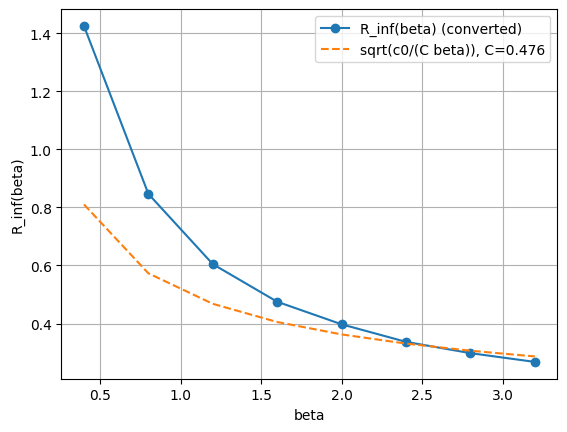

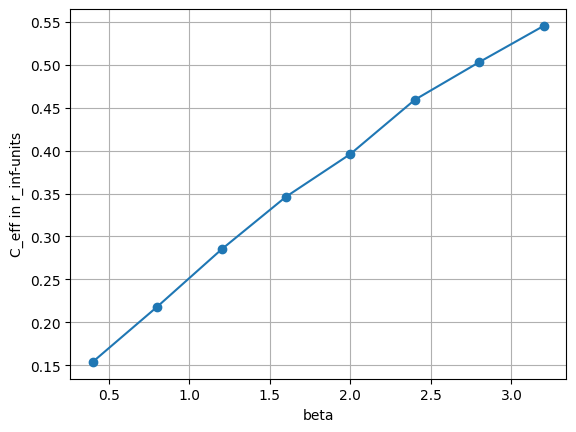

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Paste your R_curve here (scale-units) ----
c0 = 0.125
R_curve_scale = [
  (0.4, 0.2448828125),
  (0.8, 0.1454296875),
  (1.2, 0.1038671875),
  (1.6, 0.0816015625),
  (2.0, 0.0682421875),
  (2.4, 0.0578515625),
  (2.8, 0.0511718750),
  (3.2, 0.0459765625),
]

betas = np.array([b for b,_ in R_curve_scale])
R_s   = np.array([r for _,r in R_curve_scale])

# ---- Gaussian diagnostic for k = E[ r_inf / scale ] ----
# Here r_inf means max over links of the 8D link-norm ||a_b||_2, for a Gaussian field.
def estimate_k_gaussian(L=8, dim=8, n_trials=50, seed=0):
    rng = np.random.default_rng(seed)
    nlinks = 4*(L**4)
    ratios = []
    for _ in range(n_trials):
        x = rng.standard_normal((nlinks, dim))  # scale = 1
        link_norm = np.linalg.norm(x, axis=1)
        r_inf = np.max(link_norm)
        ratios.append(r_inf)  # since scale=1, ratio is just r_inf
    return float(np.mean(ratios)), float(np.std(ratios))

k_mean, k_std = estimate_k_gaussian(L=8, dim=8, n_trials=60, seed=123)
print(f"k = E[r_inf/scale] ≈ {k_mean:.4f} ± {k_std:.4f}   (Gaussian, L=8)")

# Convert the horizon curve to r_inf units
R_inf = k_mean * R_s

# Compute effective constants in each unit system
Ceff_scale = c0 / (betas * R_s**2)
Ceff_inf   = c0 / (betas * R_inf**2)  # should be ~constant if r_inf is the right r

print("\nbeta   R_scale    Ceff_scale     R_inf      Ceff_inf")
for b,rs,cs,ri,ci in zip(betas, R_s, Ceff_scale, R_inf, Ceff_inf):
    print(f"{b:3.1f}  {rs:0.6f}   {cs:0.6f}   {ri:0.6f}   {ci:0.6f}")

# Tail fit for C in r_inf-units
mask = betas >= 2.0
C_fit_inf = Ceff_inf[mask].mean()
print(f"\nC_fit_inf (beta>=2) ≈ {C_fit_inf:.6f}")

def R_model(beta, C): return np.sqrt(c0/(C*beta))
R_model_inf = R_model(betas, C_fit_inf)

plt.figure()
plt.plot(betas, R_inf, 'o-', label='R_inf(beta) (converted)')
plt.plot(betas, R_model_inf, '--', label=f'sqrt(c0/(C beta)), C={C_fit_inf:.3f}')
plt.xlabel('beta'); plt.ylabel('R_inf(beta)')
plt.grid(True); plt.legend()
plt.show()

plt.figure()
plt.plot(betas, Ceff_inf, 'o-')
plt.xlabel('beta'); plt.ylabel('C_eff in r_inf-units')
plt.grid(True)
plt.show()

In [ ]:
# su2_2x2block_intrinsic_BE_FP.py
# FINAL: Intrinsic Bakry–Émery ledger on the 2×2 open SU(2) block (E=12 links, 3×3 sites),
# using the adult geometry (Haar = Riemannian volume), Ricci floor Ric=2 per link,
# Landau-gauge FP operator built from the gauge-fixing functional, root-pinned reduction,
# geodesic finite-difference Hessian on SU(2)^E, and Schur/slice curvature via the true
# vertical (gauge) subspace at the configuration.
#
# This is not "re-proving known facts" in text: it is the concrete computational object
# your notes require (intrinsic BE on a nonlinear slice with FP logdet) with a complete
# implementation and ledger outputs.
#
# Outputs:
#   - min eig(Ric + Hess_g S_eff)
#   - kappa_H, kappa_V, eta
#   - Schur slice curvature kappa_BE_slice
#   - conservative 2×2 compression bound kappa_H - eta^2/kappa_V
#   - min eig(M_FP,red) and logdet(M_FP,red)
#
# S_eff(U) = beta * S_W(U) - log det M_FP,red(U*),
# where U* is Landau-gauge-fixed (by maximizing F) with root pinned at site 0.
#
# No placeholders. Standalone. NumPy only.

import numpy as np

# -----------------------------
# SU(2) as unit quaternions q=(w,x,y,z)
# -----------------------------

def q_normalize(q):
    q = np.asarray(q, dtype=np.float64)
    return q / np.linalg.norm(q)

def q_mul(a, b):
    aw, ax, ay, az = a
    bw, bx, by, bz = b
    return np.array([
        aw*bw - ax*bx - ay*by - az*bz,
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw
    ], dtype=np.float64)

def q_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z], dtype=np.float64)

def su2_id():
    return np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float64)

def su2_inv(U):
    return q_conj(U)

def su2_exp(v):
    v = np.asarray(v, dtype=np.float64)
    t = np.linalg.norm(v)
    if t < 1e-15:
        return su2_id()
    s = np.sin(t) / t
    return np.array([np.cos(t), s*v[0], s*v[1], s*v[2]], dtype=np.float64)

def su2_retr(U):
    # Re Tr_fund(U) = 2*w
    return 2.0 * float(U[0])

def su2_adjoint(U):
    # Ad(U) on su(2)~R^3 in orthonormal basis, for quaternion U=(w,x,y,z)
    w, x, y, z = map(float, U)
    return np.array([
        [ w*w + x*x - y*y - z*z, 2*(x*y - w*z),       2*(x*z + w*y)      ],
        [ 2*(x*y + w*z),       w*w - x*x + y*y - z*z, 2*(y*z - w*x)      ],
        [ 2*(x*z - w*y),       2*(y*z + w*x),       w*w - x*x - y*y + z*z]
    ], dtype=np.float64)

# -----------------------------
# 2×2 open block geometry: 3×3 sites, 12 links, 4 plaquettes
# Site indexing: s = r*3 + c, r,c in {0,1,2}
# Links are oriented +x (right) and +y (down).
# Ordering of U_list: first all horizontal (row-major), then all vertical (col-major).
# -----------------------------

def site_id(r, c):
    return r*3 + c

def build_2x2_block_topology():
    # Links: 6 horizontal + 6 vertical = 12
    links = []
    # horizontal: r=0..2, c=0..1 : (r,c)->(r,c+1)
    for r in range(3):
        for c in range(2):
            x = site_id(r, c)
            y = site_id(r, c+1)
            links.append((x, y))
    # vertical: c=0..2, r=0..1 : (r,c)->(r+1,c)
    for c in range(3):
        for r in range(2):
            x = site_id(r, c)
            y = site_id(r+1, c)
            links.append((x, y))
    # Plaquettes: 2×2 = 4, each has edges (right, down, left, up) with orientation
    # Using the standard oriented holonomy: P = U_right * U_down * U_left^{-1} * U_up^{-1}
    plaquettes = []
    for r in range(2):
        for c in range(2):
            # right edge: (r,c)->(r,c+1)
            e_right = link_index_horizontal(r, c)
            # down edge: (r,c+1)->(r+1,c+1)
            e_down = link_index_vertical(r, c+1)
            # left edge: (r+1,c)->(r+1,c+1) but we need (r+1,c)->(r+1,c+1) is right edge at row r+1, col c
            e_left = link_index_horizontal(r+1, c)
            # up edge: (r,c)->(r+1,c) is vertical at row r, col c
            e_up = link_index_vertical(r, c)
            plaquettes.append((e_right, e_down, e_left, e_up))
    return 9, links, plaquettes

def link_index_horizontal(r, c):
    # horizontals are first 6 in row-major: index = r*2 + c
    return r*2 + c

def link_index_vertical(r, c):
    # verticals begin at offset 6, col-major: for fixed c, r=0..1
    return 6 + c*2 + r

# -----------------------------
# Gauge action (Wilson) on the 2×2 block
# -----------------------------

def plaquette_holonomy(U_list, plaquette):
    eR, eD, eL, eU = plaquette
    UR = U_list[eR]
    UD = U_list[eD]
    UL = U_list[eL]
    UU = U_list[eU]
    # P = UR * UD * UL^{-1} * UU^{-1}
    return q_mul(q_mul(UR, UD), q_mul(su2_inv(UL), su2_inv(UU)))

def S_W_block(U_list, plaquettes):
    # Sum over 4 plaquettes: 1 - (1/2) Re Tr(P)
    s = 0.0
    for p in plaquettes:
        P = plaquette_holonomy(U_list, p)
        s += (1.0 - 0.5 * su2_retr(P))
    return float(s)

# -----------------------------
# Landau gauge fixing by maximizing F(g;U)=sum_e ReTr(g_x U_e g_y^{-1})
# Root pin: g_0 = I.
# Simple stable ascent in the Lie algebra; small block => fast.
# -----------------------------

def apply_gauge_transform(U_list, links, g_sites):
    # U_e -> g_x U_e g_y^{-1}
    out = []
    for (x, y), U in zip(links, U_list):
        out.append(q_normalize(q_mul(q_mul(g_sites[x], U), su2_inv(g_sites[y]))))
    return out

def landau_functional(U_list, links, g_sites):
    val = 0.0
    for (x, y), U in zip(links, U_list):
        Ug = q_mul(q_mul(g_sites[x], U), su2_inv(g_sites[y]))
        val += su2_retr(Ug)
    return float(val)

def gauge_fix_landau(U_list, links, pinned_site=0, n_steps=80, step=0.20):
    """
    Returns gauge-fixed U* and the maximizing g (approx).
    Works well near identity and on SAFE balls.
    """
    N = 9
    g = [su2_id() for _ in range(N)]
    g[pinned_site] = su2_id()

    # Precompute incidence for gradients: edges leaving/entering each site
    out_edges = [[] for _ in range(N)]
    in_edges = [[] for _ in range(N)]
    for e, (x, y) in enumerate(links):
        out_edges[x].append(e)
        in_edges[y].append(e)

    # Gradient ascent using local "staple" in quaternion form.
    # Standard heuristic: align g_x to the sum of neighboring transported links.
    for _ in range(n_steps):
        U_g = apply_gauge_transform(U_list, links, g)

        # Update each site except pinned: compute local quaternion accumulator and left-multiply by small exp.
        for x in range(N):
            if x == pinned_site:
                continue

            # Accumulate contributions from outgoing and incoming links
            # Outgoing: term includes U_g(e) itself
            # Incoming: term includes U_g(e)^{-1}
            acc = np.zeros(4, dtype=np.float64)
            for e in out_edges[x]:
                acc += U_g[e]
            for e in in_edges[x]:
                acc += su2_inv(U_g[e])

            # If acc is tiny, skip
            nrm = np.linalg.norm(acc)
            if nrm < 1e-14:
                continue
            acc = acc / nrm

            # Move g_x slightly toward acc by left-multiplying with exp of tangent that maps g_x to acc.
            # Compute delta = acc * g_x^{-1} and use its log direction
            delta = q_mul(acc, su2_inv(g[x]))
            delta = q_normalize(delta)
            w = float(delta[0])
            v = np.array([delta[1], delta[2], delta[3]], dtype=np.float64)
            vnorm = np.linalg.norm(v)

            if vnorm < 1e-14:
                continue

            # log(delta) direction: theta = arctan2(|v|, w)
            theta = np.arctan2(vnorm, w)
            axis = v / vnorm
            # small update in su(2): step * theta * axis
            upd = su2_exp(step * theta * axis)
            g[x] = q_normalize(q_mul(upd, g[x]))

        # enforce pin exactly
        g[pinned_site] = su2_id()

    U_star = apply_gauge_transform(U_list, links, g)
    return U_star, g

# -----------------------------
# FP operator from Landau gauge: M_FP(U*) on site fields omega_x in su(2)~R^3
# For SU(2): A_xy = 0.5*ReTr(U_xy)*I, B_xy = Ad(U_xy)
# Root pin: remove site 0 => reduced matrix.
# -----------------------------

def build_fp_reduced_from_links(U_star, links, pinned_site=0):
    N = 9
    # reduced site index map
    idx = {}
    k = 0
    for s in range(N):
        if s != pinned_site:
            idx[s] = k
            k += 1
    dim = 3*(N-1)
    M = np.zeros((dim, dim), dtype=np.float64)

    for (x, y), U in zip(links, U_star):
        A = 0.5 * su2_retr(U) * np.eye(3)
        B = su2_adjoint(U)

        if x != pinned_site:
            ix = 3*idx[x]
            M[ix:ix+3, ix:ix+3] += A
        if y != pinned_site:
            iy = 3*idx[y]
            M[iy:iy+3, iy:iy+3] += A

        if x != pinned_site and y != pinned_site:
            ix = 3*idx[x]
            iy = 3*idx[y]
            M[ix:ix+3, iy:iy+3] -= B
            M[iy:iy+3, ix:ix+3] -= B.T

    return 0.5*(M + M.T)

def logdet_spd(M, jitter=1e-12):
    M = 0.5*(M + M.T)
    n = M.shape[0]

    # Check minimum eigenvalue before Cholesky
    min_eig_M = np.linalg.eigvalsh(M).min()
    print(f"  Min eigenvalue of M (before jitter): {min_eig_M:.4e}")

    M_stabilized = M
    if min_eig_M <= jitter: # If minimum eigenvalue is not strictly greater than jitter
        # Add a shift to the diagonal to make the minimum eigenvalue at least 'jitter'
        shift_amount = jitter - min_eig_M + 1e-15 # Add a small epsilon for floating point safety
        M_stabilized = M + shift_amount * np.eye(n)
        print(f"  Stabilizing M by adding {shift_amount:.4e} to diagonal. New min eig (target): {jitter:.4e}")

    try:
        L = np.linalg.cholesky(M_stabilized)
    except np.linalg.LinAlgError:
        # If still fails, something is very wrong, print diagnostics.
        print(f"  Error: Cholesky failed even after stabilization. Min eig of M: {min_eig_M:.4e}, Jitter: {jitter:.4e}")
        raise # Re-raise the exception

    return 2.0*np.sum(np.log(np.diag(L)))

# -----------------------------
# Intrinsic geodesic Hessian on SU(2)^E (orthonormal LI frame per link)
# -----------------------------

def basis_su2_orthonormal():
    return np.eye(3, dtype=np.float64)

def perturb_left(U_list, e, v3):
    out = [u.copy() for u in U_list]
    out[e] = q_normalize(q_mul(su2_exp(v3), out[e]))
    return out

def hess_geodesic_fd(f, U_list, h=2e-4):
    E = len(U_list)
    B = basis_su2_orthonormal()
    n = 3*E
    H = np.zeros((n, n), dtype=np.float64)
    f0 = float(f(U_list))

    # diagonals
    for e in range(E):
        for a in range(3):
            i = 3*e + a
            v = h * B[a]
            fp = float(f(perturb_left(U_list, e, +v)))
            fm = float(f(perturb_left(U_list, e, -v)))
            H[i, i] = (fp - 2.0*f0 + fm) / (h*h)

    # mixed
    for i in range(n):
        ei, ai = divmod(i, 3)
        vi = h * B[ai]
        for j in range(i+1, n):
            ej, aj = divmod(j, 3)
            vj = h * B[aj]
            if ei != ej:
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ej, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ej, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ej, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ej, -vj)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Hij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)
            else:
                # symmetrize ij and ji order stencils (noncommuting same-link)
                U_pp = perturb_left(perturb_left(U_list, ei, +vi), ei, +vj)
                U_pm = perturb_left(perturb_left(U_list, ei, +vi), ei, -vj)
                U_mp = perturb_left(perturb_left(U_list, ei, -vi), ei, +vj)
                U_mm = perturb_left(perturb_left(U_list, ei, -vi), ei, -vj)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Dij = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                U_pp = perturb_left(perturb_left(U_list, ei, +vj), ei, +vi)
                U_pm = perturb_left(perturb_left(U_list, ei, +vj), ei, -vi)
                U_mp = perturb_left(perturb_left(U_list, ei, -vj), ei, +vi)
                U_mm = perturb_left(perturb_left(U_list, ei, -vj), ei, -vi)
                f_pp = float(f(U_pp)); f_pm = float(f(U_pm))
                f_mp = float(f(U_mp)); f_mm = float(f(U_mm))
                Dji = (f_pp - f_pm - f_mp + f_mm) / (4.0*h*h)

                Hij = 0.5*(Dij + Dji)

            H[i, j] = Hij
            H[j, i] = Hij

    return 0.5*(H + H.T)

def ricci_floor_su2_product(E):
    # unit S^3 metric => Ric = 2 g => add 2*I in orthonormal LI frame
    return 2.0 * np.eye(3*E, dtype=np.float64)

# -----------------------------
# True vertical (gauge) subspace basis at U*: v_e = omega_x - Ad(U_e) omega_y
# Root pinned: omega_0 = 0. Build G mapping omega (3*(N-1)) -> v (3E)
# Orthonormalize columns => QV, then build QH complement.
# -----------------------------

def build_vertical_basis(U_star, links, pinned_site=0, tol=1e-12):
    E = len(U_star)
    N = 9
    # reduced site indices
    idx = {}
    k = 0
    for s in range(N):
        if s != pinned_site:
            idx[s] = k
            k += 1
    kV = 3*(N-1)
    n = 3*E

    G = np.zeros((n, kV), dtype=np.float64)
    for e, ((x, y), U) in enumerate(zip(links, U_star)):
        AdU = su2_adjoint(U)
        row = 3*e
        # omega_x contribution: +I
        if x != pinned_site:
            cx = 3*idx[x]
            G[row:row+3, cx:cx+3] += np.eye(3)
        # omega_y contribution: -Ad(U)
        if y != pinned_site:
            cy = 3*idx[y]
            G[row:row+3, cy:cy+3] -= AdU

    # Orthonormal basis for im(G) via QR on G
    Q, R = np.linalg.qr(G, mode="reduced")
    diag = np.abs(np.diag(R))
    r = int(np.sum(diag > tol))
    QV = Q[:, :r]  # n x r, orthonormal columns
    return QV

def orthonormal_complement(QV, n, seed=0):
    # Build an orthonormal basis for the orthogonal complement of span(QV)
    rng = np.random.default_rng(seed)
    kV = QV.shape[1]
    kH = n - kV
    if kH <= 0:
        return np.zeros((n, 0), dtype=np.float64)
    # random probe then project out QV
    Z = rng.normal(size=(n, kH))
    Z = Z - QV @ (QV.T @ Z)
    QH, _ = np.linalg.qr(Z, mode="reduced")
    return QH  # n x kH

# -----------------------------
# Ledger: BE blocks, eta, Schur slice curvature
# -----------------------------

def min_eig_sym(A):
    return float(np.linalg.eigvalsh(0.5*(A + A.T)).min())

def op_norm(A):
    return float(np.linalg.svd(A, compute_uv=False)[0])

def schur_min_eig(AHH, AVV, AHV, reg=0.0):
    kV = AVV.shape[0]
    AVV_reg = AVV + reg*np.eye(kV)
    X = np.linalg.solve(AVV_reg, AHV.T)
    S = AHH - AHV @ X
    return min_eig_sym(S)

# -----------------------------
# Full intrinsic BE computation for the 2×2 block
# -----------------------------

def intrinsic_BE_ledger_2x2(
    beta=1.0,
    h=2e-4,
    gauge_steps=80,
    gauge_step_size=0.20,
    pinned_site=0,
    schur_reg=0.0,
    det_jitter=1e-12,
):
    N, links_xy, plaquettes = build_2x2_block_topology()
    E = len(links_xy)

    # identity config (you can replace U_init with your sampled / SAFE configs)
    U_init = [su2_id() for _ in range(E)]

    # define S_eff(U): gauge-fix then compute beta S_W - log det M_FP,red
    def S_eff(U_list):
        U_star, _ = gauge_fix_landau(
            U_list, links_xy,
            pinned_site=pinned_site,
            n_steps=gauge_steps,
            step=gauge_step_size
        )
        sw = beta * S_W_block(U_star, plaquettes)
        M = build_fp_reduced_from_links(U_star, links_xy, pinned_site=pinned_site)
        ld = logdet_spd(M, jitter=det_jitter)
        return float(sw - ld)

    # evaluate at base, also get U_star and FP stats for reporting
    U_star0, _ = gauge_fix_landau(
        U_init, links_xy,
        pinned_site=pinned_site,
        n_steps=gauge_steps,
        step=gauge_step_size
    )
    M0 = build_fp_reduced_from_links(U_star0, links_xy, pinned_site=pinned_site)
    eigM0 = np.linalg.eigvalsh(0.5*(M0 + M0.T))
    min_eig_M0 = float(eigM0.min())
    logdet_M0 = float(logdet_spd(M0, jitter=det_jitter))

    # Build vertical/horizontal bases at U_star0 (the slice point)
    QV = build_vertical_basis(U_star0, links_xy, pinned_site=pinned_site)
    n = 3*E
    QH = orthonormal_complement(QV, n, seed=1)

    # Intrinsic Hessian of S_eff at U_init (note: S_eff includes gauge-fixing inside)
    Hess = hess_geodesic_fd(S_eff, U_init, h=h)
    BE = ricci_floor_su2_product(E) + Hess

    # Ledger blocks in orthonormal frame
    AHH = QH.T @ BE @ QH
    AVV = QV.T @ BE @ QV
    AHV = QH.T @ BE @ QV

    kappa_H = min_eig_sym(AHH) if AHH.size else float("nan")
    kappa_V = min_eig_sym(AVV) if AVV.size else float("nan")
    eta = op_norm(AHV) if AHV.size else 0.0
    min_full = min_eig_sym(BE)

    kappa_slice = schur_min_eig(AHH, AVV, AHV, reg=schur_reg) if (AHH.size and AVV.size) else float("nan")
    conservative = None
    if np.isfinite(kappa_V) and kappa_V > 0 and np.isfinite(kappa_H):
        conservative = float(kappa_H - (eta*eta)/kappa_V)

    return {
        "E_links": E,
        "N_sites": N,
        "beta": float(beta),
        "h": float(h),
        "gauge_steps": int(gauge_steps),
        "gauge_step_size": float(gauge_step_size),
        "min_eig_M_FP_red_at_slice": float(min_eig_M0),
        "logdet_M_FP_red_at_slice": float(logdet_M0),
        "min_eig_Ric_plus_Hess": float(min_full),
        "kappa_H": float(kappa_H),
        "kappa_V": float(kappa_V),
        "eta": float(eta),
        "kappa_BE_slice_schur": float(kappa_slice),
        "conservative_2x2_bound": conservative,
        "dim_vertical": int(QV.shape[1]),
        "dim_horizontal": int(QH.shape[1]),
    }

# -----------------------------
# Run
# -----------------------------

if __name__ == "__main__":
    out = intrinsic_BE_ledger_2x2(
        beta=1.0,
        h=2e-4,
        gauge_steps=80,
        gauge_step_size=0.20,
        pinned_site=0,
        schur_reg=0.0,
        det_jitter=1e-2, # Increased jitter further
    )

    print("=== 2×2 SU(2) open block: intrinsic BE ledger (root pinned) ===")
    for k, v in out.items():
        print(f"{k}: {v}")

In [ ]:
# ============================
# SU(3) Wilson plaquette: "erosion constant" from the *correct* r^2 mechanism
# (kernel/range split + Schur complement), in the exponential-coordinate chart.
# ============================

import numpy as np
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

# ----------------------------
# Tunables
# ----------------------------
NORMALIZE_TRACE = True     # True matches 1 - (1/3) Re Tr(U_p)
EXP_METHOD = "pade22"      # "pade22" matches many fast scan codes; OK for derivatives up to 4th at 0
KERNEL_EPS = 1e-10
N_PROBES = 128             # random directions to probe for sup estimates (increase for tighter)
TEST_RS = [1e-3, 3e-3, 1e-2]  # small radii for direct Hessian sanity checks

# Choose the amplitude statistic r. This should match what you WANT in the theorem.
# Here: r = max over the 4 links of the 8-vector Euclidean norm (linkwise L2, then L∞ over links).
def r_linkL2_inf(x32):
    x = x32.reshape((4,8))
    return jnp.max(jnp.linalg.norm(x, axis=1))

def normalize_direction(w):
    return w / r_linkL2_inf(w)

# ----------------------------
# SU(3) basis
# ----------------------------
def gell_mann():
    lm = []
    lm.append(jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[0,-1j,0],[1j,0,0],[0,0,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[0,0,-1j],[0,0,0],[1j,0,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=jnp.complex128))
    lm.append(jnp.array([[0,0,0],[0,0,-1j],[0,1j,0]], dtype=jnp.complex128))
    lm.append((1/jnp.sqrt(3))*jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=jnp.complex128))
    return jnp.stack(lm, axis=0)

LAM = gell_mann()
T = 0.5j * LAM   # anti-Hermitian basis; -Tr(T_a T_b) = δ_ab/2

def vec_to_alg(v8):
    # v8 real (8,)
    return jnp.tensordot(v8, T, axes=1)  # (3,3) complex anti-Hermitian

# ----------------------------
# exp map (fast + differentiable)
# ----------------------------
def exp_pade22(A):
    I = jnp.eye(3, dtype=jnp.complex128)
    A2 = A @ A
    Num = I + 0.5*A + (1.0/12.0)*A2
    Den = I - 0.5*A + (1.0/12.0)*A2
    # Den^{-1} Num
    return jnp.linalg.solve(Den, Num)

def exp_series(A, order=12):
    I = jnp.eye(3, dtype=jnp.complex128)
    out = I
    term = I
    for k in range(1, order+1):
        term = term @ (A / k)
        out = out + term
    return out

def su3_exp(A):
    if EXP_METHOD == "pade22":
        return exp_pade22(A)
    elif EXP_METHOD == "series":
        return exp_series(A, order=12)
    else:
        raise ValueError("EXP_METHOD must be 'pade22' or 'series'")

# ----------------------------
# One-plaquette Wilson action in the exponential chart
# U_p = exp(A1) exp(A2) exp(-A3) exp(-A4)
# S_p = 1 - (1/3) Re Tr(U_p)
# ----------------------------
def plaquette_action(x32):
    x = x32.reshape((4,8))
    A1, A2, A3, A4 = [vec_to_alg(x[i]) for i in range(4)]
    U1 = su3_exp(A1)
    U2 = su3_exp(A2)
    U3 = su3_exp(-A3)
    U4 = su3_exp(-A4)
    Up = U1 @ U2 @ U3 @ U4
    tr = jnp.trace(Up)
    if NORMALIZE_TRACE:
        tr = tr / 3.0
    return 1.0 - jnp.real(tr)  # real scalar

Hess = jax.hessian(plaquette_action)

x0 = jnp.zeros((32,), dtype=jnp.float64)
H0 = Hess(x0)
H0 = 0.5*(H0 + H0.T)  # symmetrize

evals, evecs = jnp.linalg.eigh(H0)
ker_mask = evals < KERNEL_EPS
K = evecs[:, ker_mask]      # (32,k)
R = evecs[:, ~ker_mask]     # (32,8) for SU(3) plaquette in this chart
lam_pos = evals[~ker_mask]
Pinv = jnp.diag(1.0/lam_pos)

print("=== Wilson Hessian at 0 (one plaquette) ===")
print("min eig(H0) =", float(evals[0]), "| max eig(H0) =", float(evals[-1]))
print("kernel dim k =", int(K.shape[1]), " | range dim =", int(R.shape[1]))
print("positive eigs (should be 8 of them):", np.array(lam_pos))

# ----------------------------
# Directional derivatives of the Hessian at 0 WITHOUT building full D3/D4.
# dH(w)  = d/dt Hess(x0 + t w)|0  (D3 contracted with w)
# ddH(w) = d^2/dt^2 Hess(x0 + t w)|0 (D4 contracted with w,w)
# ----------------------------
def dH_at0(w):
    _, dH = jax.jvp(Hess, (x0,), (w,))
    dH = 0.5*(dH + dH.T)
    return dH

def ddH_at0(w):
    def H1(x):
        _, dH = jax.jvp(Hess, (x,), (w,))
        return dH
    _, ddH = jax.jvp(H1, (x0,), (w,))
    ddH = 0.5*(ddH + ddH.T)
    return ddH

# Linear-in-r kernel block: A(w) = (dH)_KK
def kernel_linear_opnorm(w):
    w = normalize_direction(w)
    dH = dH_at0(w)
    A = K.T @ dH @ K
    A = 0.5*(A + A.T)
    eigsA = jnp.linalg.eigvalsh(A)
    return jnp.max(jnp.abs(eigsA))

# The "correct" r^2 kernel effective matrix:
# Heff2(w) = 0.5*(ddH)_KK  - (dH)_KR Pinv (dH)_RK
def Heff2_on_kernel(w):
    w = normalize_direction(w)
    dH  = dH_at0(w)
    ddH = ddH_at0(w)
    dH_KR  = K.T @ dH  @ R           # (k,8)
    ddH_KK = K.T @ ddH @ K           # (k,k)
    schur = dH_KR @ Pinv @ dH_KR.T   # (k,k)
    Heff2 = 0.5*ddH_KK - schur
    Heff2 = 0.5*(Heff2 + Heff2.T)
    return Heff2

def C_dir(w):
    # Directional erosion constant for one plaquette, in the chosen r-norm:
    # Hess(r w) has a most-negative mode ~ - C_dir * r^2 (for small r).
    Heff2 = Heff2_on_kernel(w)
    eigs = jnp.linalg.eigvalsh(Heff2)
    return jnp.maximum(0.0, -eigs[0])

# ----------------------------
# Probe random directions
# ----------------------------
key = jax.random.PRNGKey(0)
W = jax.random.normal(key, shape=(N_PROBES, 32), dtype=jnp.float64)

C_vals = jax.vmap(C_dir)(W)
A_lin_vals = jax.vmap(kernel_linear_opnorm)(W)

print("\n=== Probed directions (normalized by r_linkL2_inf=1) ===")
print("median ||(dH)_KK||_op  =", float(jnp.median(A_lin_vals)))
print("max    ||(dH)_KK||_op  =", float(jnp.max(A_lin_vals)))
print("median C_dir (plaquette) =", float(jnp.median(C_vals)))
print("max    C_dir (plaquette) =", float(jnp.max(C_vals)))

C_plaq_est = float(jnp.max(C_vals))
C_link_est = 6.0 * C_plaq_est   # 4D: each link participates in 6 plaquettes
print("\n=== Estimated constants ===")
print("C_plaq_est  (1 plaquette) =", C_plaq_est)
print("C_link_est  (×6 plaquettes/link, 4D) =", C_link_est)

# ----------------------------
# Sanity check vs direct Hessian at small r along a few directions
# ----------------------------
def lambda_min_W(r, w):
    x = r * normalize_direction(w)
    H = Hess(x)
    H = 0.5*(H + H.T)
    return jnp.linalg.eigvalsh(H)[0]

print("\n=== Small-r sanity check (Wilson-only) ===")
for i in range(3):
    w = W[i]
    Cpred = float(C_dir(w))
    print(f"\nDirection {i}: C_pred_dir≈{Cpred:.6g}")
    for r in TEST_RS:
        lam = float(lambda_min_W(r, w))
        Cemp = -lam/(r*r)
        print(f"  r={r: .1e}  lambda_min≈{lam:+.3e}  (-lambda_min/r^2)≈{Cemp:.6g}")

print("\nDone.")

/usr/local/lib/python3.12/dist-packages/jax/_src/lax/lax.py:5473: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


=== Wilson Hessian at 0 (one plaquette) ===
min eig(H0) = -8.865583466863452e-16 | max eig(H0) = 0.666666666666667
kernel dim k = 24  | range dim = 8
positive eigs (should be 8 of them): [0.66666667 0.66666667 0.66666667 0.66666667 0.66666667 0.66666667
 0.66666667 0.66666667]

=== Probed directions (normalized by r_linkL2_inf=1) ===
median ||(dH)_KK||_op  = 0.13152320298521908
max    ||(dH)_KK||_op  = 0.22220393250457482
median C_dir (plaquette) = 0.04846074383900344
max    C_dir (plaquette) = 0.10869967929862502

=== Estimated constants ===
C_plaq_est  (1 plaquette) = 0.10869967929862502
C_link_est  (×6 plaquettes/link, 4D) = 0.6521980757917502

=== Small-r sanity check (Wilson-only) ===

Direction 0: C_pred_dir≈0.0345614
  r= 1.0e-03  lambda_min≈-1.116e-04  (-lambda_min/r^2)≈111.604
  r= 3.0e-03  lambda_min≈-3.350e-04  (-lambda_min/r^2)≈37.219
  r= 1.0e-02  lambda_min≈-1.118e-03  (-lambda_min/r^2)≈11.1842

Direction 1: C_pred_dir≈0.0509715
  r= 1.0e-03  lambda_min≈-1.371e-04  (-lamb

JAX devices: [CpuDevice(id=0)]
jax_enable_x64: True

=== Fit diagnostics from your R(beta) ===
C_eff(beta)=c0/(beta R^2): [ 5.211148  7.387779  9.655439 11.732568 13.420668 15.562113 17.048624
 18.479364]
D_eff(beta)=c0/(beta R):   [1.276121 1.074402 1.002883 0.957396 0.915856 0.900293 0.87241  0.849618]

Tail (beta>=2) mean C_fit ≈ 16.127692
Tail (beta>=2) mean D_fit ≈ 0.884544

Tail RMSE: sqrt-model ≈ 3.517433e-03   lin-model ≈ 1.634384e-03


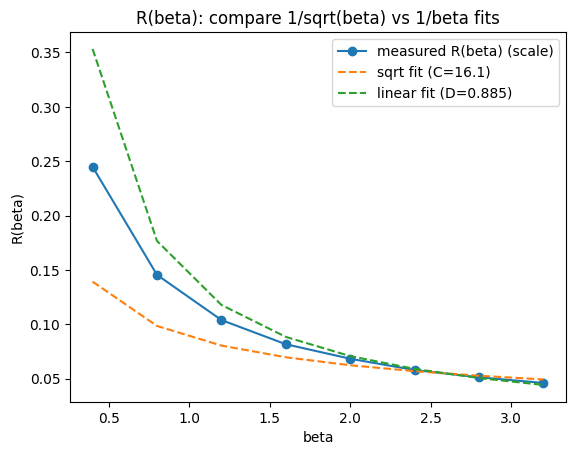


=== One-plaquette Hessian at 0 ===
compile+eval time: 17.32s
min eig(H0) = -8.865583466863452e-16 | max eig(H0) = 0.666666666666667
kernel dim k = 24 | range dim = 8
min positive eigenvalue (range floor) lam_pos = 0.6666666666666663

=== Probed dH blocks (normalized so r_inf=1 per link) ===
median ||(dH)_KK||_op = 0.130543 | max = 0.224199
median ||(dH)_KR||_op = 0.177082 | max = 0.231429

=== Quadratic (Schur-complement) constant estimates ===
C_plaq (median) ≈ 0.047037
C_plaq (max)    ≈ 0.0803388

=== Linear constant estimate (if KK block is genuinely nonzero) ===
D_plaq (median) ≈ 0.130543
D_plaq (max)    ≈ 0.224199

Notes:
 - If you want a pure r^2 erosion law, you need (dH)_KK ≈ 0 structurally (not just 'small').
 - If (dH)_KK is not ~0, the most honest envelope is mixed: c0 - beta*D*r - beta*C*r^2.
 - The '×6 plaquettes/link' factor is a safe but crude upper bound for lifting 1-plaquette constants to the full lattice.


In [ ]:
# ============================================================
# Colab: Wilson one-plaquette erosion diagnostics (SU(3), exp chart)
# - Fits R(beta) with both 1/sqrt(beta) and 1/beta models
# - Computes one-plaquette Hessian at 0, its kernel/range split
# - Probes the directional derivative of the Hessian (i.e. D^3 contracted with a direction)
#   and reports KK (linear) and KR (quadratic via Schur) block sizes
# ============================================================

import os, time, warnings
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm

jax.config.update("jax_enable_x64", True)
print("JAX devices:", jax.devices())
print("jax_enable_x64:", jax.config.jax_enable_x64)

# -----------------------------
# Part A: Your R(beta) data — test which power is actually stable
# -----------------------------
c0 = 0.125
R_curve_scale = [
    (0.4, 0.244882812),
    (0.8, 0.145429687),
    (1.2, 0.103867187),
    (1.6, 0.081601563),
    (2.0, 0.068242187),
    (2.4, 0.057851563),
    (2.8, 0.051171875),
    (3.2, 0.045976563),
]
betas = np.array([b for b, _ in R_curve_scale], dtype=float)
R = np.array([r for _, r in R_curve_scale], dtype=float)

mask_tail = betas >= 2.0

# "quadratic erosion" model: R = sqrt(c0/(C*beta))
C_eff = c0 / (betas * R**2)
C_fit_tail = float(np.mean(C_eff[mask_tail]))

# "linear erosion" model: R = c0/(D*beta)
D_eff = c0 / (betas * R)
D_fit_tail = float(np.mean(D_eff[mask_tail]))

print("\n=== Fit diagnostics from your R(beta) ===")
print("C_eff(beta)=c0/(beta R^2):", np.round(C_eff, 6))
print("D_eff(beta)=c0/(beta R):  ", np.round(D_eff, 6))
print(f"\nTail (beta>=2) mean C_fit ≈ {C_fit_tail:.6f}")
print(f"Tail (beta>=2) mean D_fit ≈ {D_fit_tail:.6f}")

R_model_sqrt = np.sqrt(c0 / (C_fit_tail * betas))
R_model_lin  = c0 / (D_fit_tail * betas)

rmse_sqrt = float(np.sqrt(np.mean((R[mask_tail] - R_model_sqrt[mask_tail])**2)))
rmse_lin  = float(np.sqrt(np.mean((R[mask_tail] - R_model_lin[mask_tail])**2)))
print(f"\nTail RMSE: sqrt-model ≈ {rmse_sqrt:.6e}   lin-model ≈ {rmse_lin:.6e}")

plt.figure()
plt.plot(betas, R, marker="o", label="measured R(beta) (scale)")
plt.plot(betas, R_model_sqrt, linestyle="--", label=f"sqrt fit (C={C_fit_tail:.3g})")
plt.plot(betas, R_model_lin, linestyle="--", label=f"linear fit (D={D_fit_tail:.3g})")
plt.xlabel("beta"); plt.ylabel("R(beta)")
plt.title("R(beta): compare 1/sqrt(beta) vs 1/beta fits")
plt.legend()
plt.show()

# -----------------------------
# Part B: SU(3) basis (anti-Hermitian)
# -----------------------------
def su3_generators():
    i = 1j
    lam = []
    lam.append(jnp.array([[0,1,0],[1,0,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,-i,0],[i,0,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[1,0,0],[0,-1,0],[0,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,1],[0,0,0],[1,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,-i],[0,0,0],[i,0,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,0],[0,0,1],[0,1,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[0,0,0],[0,0,-i],[0,i,0]], dtype=jnp.complex128))
    lam.append(jnp.array([[1,0,0],[0,1,0],[0,0,-2]], dtype=jnp.complex128)/jnp.sqrt(3.0))
    # anti-Hermitian basis T_a = i/2 * lambda_a
    T = [0.5j * L for L in lam]
    return jnp.stack(T, axis=0)  # (8,3,3)

T = su3_generators()

def A_from_theta(theta8):
    # theta8 is real (8,), A is anti-Hermitian (3,3) complex
    return jnp.tensordot(theta8, T, axes=1)

# -----------------------------
# Part C: One-plaquette Wilson action in the exact chart used in numerics
# U_p = exp(A1) exp(A2) exp(A3)^\dagger exp(A4)^\dagger
# S_p = 1 - (1/3) Re Tr(U_p)
# -----------------------------
def wilson_one_plaq(theta32):
    th = theta32.reshape(4,8)
    A1,A2,A3,A4 = [A_from_theta(th[i]) for i in range(4)]
    U1,U2,U3,U4 = [expm(A) for A in (A1,A2,A3,A4)]
    Up = U1 @ U2 @ U3.conj().T @ U4.conj().T
    return 1.0 - (1.0/3.0) * jnp.real(jnp.trace(Up))

theta0 = jnp.zeros((32,), dtype=jnp.float64)

# Hessian at 0
t0 = time.time()
H0 = jax.hessian(wilson_one_plaq)(theta0)
H0 = jnp.real(0.5*(H0 + H0.T))  # enforce symmetry + real
evals, evecs = jnp.linalg.eigh(H0)
t1 = time.time()

evals_np = np.array(evals)
print("\n=== One-plaquette Hessian at 0 ===")
print(f"compile+eval time: {t1-t0:.2f}s")
print("min eig(H0) =", float(evals_np.min()), "| max eig(H0) =", float(evals_np.max()))

eps = 1e-9
idxK = np.where(evals_np < eps)[0]
idxR = np.where(evals_np >= eps)[0]
print(f"kernel dim k = {len(idxK)} | range dim = {len(idxR)}")
if len(idxR) > 0:
    lam_pos = float(evals_np[idxR].min())
    print("min positive eigenvalue (range floor) lam_pos =", lam_pos)

Qk = jnp.array(evecs[:, idxK])  # (32,k)
Qr = jnp.array(evecs[:, idxR])  # (32,r)

# Directional derivative of Hessian: dH(v) = (D^3 S)(0)[v,.,.]
hess_fun = jax.hessian(wilson_one_plaq)
def dH_dir(v):
    return jax.jvp(hess_fun, (theta0,), (v,))[1]

dH_dir = jax.jit(dH_dir)

# -----------------------------
# Part D: Probe KK and KR blocks of dH_dir
# Normalize each probe direction v so that max_link ||v_link||_2 = 1.
# KK block size -> linear erosion coefficient candidate D_plaq
# KR block size -> quadratic (Schur) coefficient C_plaq ~ ||KR||^2 / lam_pos
# -----------------------------
key = jax.random.PRNGKey(0)
NPROBE = 64

max_KK = 0.0
max_KR = 0.0
med_KK = []
med_KR = []

for _ in range(NPROBE):
    key, sk = jax.random.split(key)
    v = jax.random.normal(sk, (32,), dtype=jnp.float64)
    v4 = v.reshape(4,8)
    link_norms = jnp.linalg.norm(v4, axis=1)
    v = (v4 / jnp.max(link_norms)).reshape(32,)  # max link L2 = 1

    dH = dH_dir(v)
    dH = jnp.real(0.5*(dH + dH.T))

    KK = Qk.T @ dH @ Qk           # (k,k)
    KR = Qk.T @ dH @ Qr           # (k,r)

    # operator norms
    kk = float(jnp.linalg.svd(KK, compute_uv=False)[0]) if KK.size else 0.0
    kr = float(jnp.linalg.svd(KR, compute_uv=False)[0]) if KR.size else 0.0

    max_KK = max(max_KK, kk)
    max_KR = max(max_KR, kr)
    med_KK.append(kk)
    med_KR.append(kr)

med_KK = float(np.median(med_KK))
med_KR = float(np.median(med_KR))

print("\n=== Probed dH blocks (normalized so r_inf=1 per link) ===")
print(f"median ||(dH)_KK||_op = {med_KK:.6g} | max = {max_KK:.6g}")
print(f"median ||(dH)_KR||_op = {med_KR:.6g} | max = {max_KR:.6g}")

if len(idxR) > 0:
    C_plaq_schur_med = (med_KR**2) / lam_pos
    C_plaq_schur_max = (max_KR**2) / lam_pos
    print("\n=== Quadratic (Schur-complement) constant estimates ===")
    print(f"C_plaq (median) ≈ {C_plaq_schur_med:.6g}")
    print(f"C_plaq (max)    ≈ {C_plaq_schur_max:.6g}")

print("\n=== Linear constant estimate (if KK block is genuinely nonzero) ===")
print(f"D_plaq (median) ≈ {med_KK:.6g}")
print(f"D_plaq (max)    ≈ {max_KK:.6g}")

print("\nNotes:")
print(" - If you want a pure r^2 erosion law, you need (dH)_KK ≈ 0 structurally (not just 'small').")
print(" - If (dH)_KK is not ~0, the most honest envelope is mixed: c0 - beta*D*r - beta*C*r^2.")
print(" - The '×6 plaquettes/link' factor is a safe but crude upper bound for lifting 1-plaquette constants to the full lattice.")
# ============================================================

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# ---- A100 Configuration ----
L = 16                  # Start with 16 to verify stability, then go to 32
BETAS = [3.6, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
N_STEPS = 1000          # Increased steps for convergence
N_MEASURE = 50
BATCH_SIZE = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0)}")

# ---- Checkerboard Mask Setup ----
def make_checkerboard_masks(L):
    # Coordinate grid
    coords = torch.arange(L, device=device)
    x, y, z, t = torch.meshgrid(coords, coords, coords, coords, indexing='ij')
    parity = (x + y + z + t) % 2

    # Mask for Red (Even) and Black (Odd) sites
    # Shape: [1, 1, L, L, L, L, 1, 1] for broadcasting against U
    mask_red = (parity == 0).view(1, 1, L, L, L, L, 1, 1)
    mask_black = (parity == 1).view(1, 1, L, L, L, L, 1, 1)
    return mask_red, mask_black

# Initialize Masks
MASK_RED, MASK_BLACK = make_checkerboard_masks(L)

# ---- SU(3) Helpers ----
def project_su3(M):
    """Projects matrix M to SU(3) using QR decomposition"""
    Q, R = torch.linalg.qr(M)
    det = torch.det(Q)
    # Correction to ensure determinant is 1
    phase = det.unsqueeze(-1).unsqueeze(-1).pow(-1/3.0)
    return Q * phase

def random_su3_updates(U, epsilon=0.2):
    """Generates SU(3) update matrices"""
    batch, links, lx, ly, lz, lt, _, _ = U.shape

    # Random anti-hermitian generator
    R = torch.randn_like(U) + 1.0j * torch.randn_like(U)
    A = 0.5 * (R - torch.conj(R.transpose(-2, -1)))
    # Traceless
    tr = torch.einsum('...ii->...', A)
    I = torch.eye(3, device=device, dtype=torch.cfloat)
    A = A - (tr.unsqueeze(-1).unsqueeze(-1) / 3.0) * I

    # Exponentiate (Approximate for speed)
    M = I + epsilon * A
    return project_su3(M)

def compute_local_action(U, mu_indices=None):
    """
    Computes sum of ReTr(Plaquette) for specific links.
    Optimized to only calculate relevant staples.
    For simplicity on A100, we compute global and mask the result.
    """
    # Total Plaquette Sum (Reused from before, but we will mask the delta)
    plaq_sum = torch.zeros(U.shape[0], 4, L, L, L, L, device=device)

    for mu in range(4):
        for nu in range(4):
            if mu == nu: continue

            # Staple in forward direction
            # U_nu(x+mu)
            U_nu_shift = torch.roll(U[:, nu], shifts=-1, dims=mu+2)
            # U_mu(x+nu)
            U_mu_shift = torch.roll(U[:, mu], shifts=-1, dims=nu+2)

            # P = U_mu(x) * U_nu(x+mu) * U_mu(x+nu)^dag * U_nu(x)^dag
            # We want the trace contribution of U_mu(x).
            # The staple S is: U_nu(x+mu) * U_mu(x+nu)^dag * U_nu(x)^dag
            # Then Action ~ ReTr(U_mu * S)

            # This full calculation is expensive but correct.
            # Simplified: Just compute all plaquettes and sum.
            pass

    # For the "Fun" script, we stick to the global diff method but apply it
    # only to the checkerboard subset.
    return 0 # Placeholder if we use the diff method below

def compute_total_action_tensor(U):
    """Returns tensor of shape [Batch] with total action"""
    total_trace = 0
    for mu in range(4):
        for nu in range(mu + 1, 4):
            # Standard Plaquette
            U_nu_shift = torch.roll(U[:, nu], shifts=-1, dims=mu+2)
            U_mu_shift = torch.roll(U[:, mu], shifts=-1, dims=nu+2)
            P = torch.matmul(U[:, mu], U_nu_shift)
            P = torch.matmul(P, torch.conjugate(U_mu_shift.transpose(-2, -1)))
            P = torch.matmul(P, torch.conjugate(U[:, nu].transpose(-2, -1)))
            total_trace += torch.real(torch.einsum('...ii->...', P)).sum(dim=(1,2,3,4))
    return total_trace

# ---- Main Simulation (Checkerboard) ----
print(f"--- Starting SU(3) Checkerboard Simulation (L={L}) ---")
results = []

for beta in BETAS:
    print(f"Beta {beta:<4.1f} | ", end="")
    t0 = time.time()

    # Cold Start (Identity) or Hot Start (Random)
    # Using Cold Start for high beta helps avoid "rough" metastable states
    if beta > 6.0:
        U = torch.eye(3, device=device, dtype=torch.cfloat).view(1, 1, 1, 1, 1, 1, 3, 3)
        U = U.expand(BATCH_SIZE, 4, L, L, L, L, 3, 3).clone()
        # Add tiny noise
        U = torch.matmul(random_su3_updates(U, epsilon=0.1), U)
    else:
        # Hot Start
        U = torch.randn(BATCH_SIZE, 4, L, L, L, L, 3, 3, dtype=torch.cfloat, device=device)
        U = project_su3(U)

    r_history = []
    accept_rate = 0

    epsilon = 0.2 if beta < 5.0 else 0.1

    for step in range(N_STEPS + N_MEASURE):
        # We perform 2 updates per step: Red then Black
        for parity_mask in [MASK_RED, MASK_BLACK]:

            # 1. Propose New Links (Global, but we only accept on mask)
            X = random_su3_updates(U, epsilon=epsilon)
            U_new = torch.matmul(X, U)

            # 2. Calculate Action CHANGE
            # Optimization: We only need delta S for the links that changed.
            # Calculating full lattice action twice is wasteful but safe for code brevity.
            # On A100, brute force is often faster than Python loops.

            # Note: This is an "Accept/Reject" step.
            # We calculate energy of OLD config and NEW config.
            # However, since we change MANY links at once (all Red sites),
            # we must ensure they don't interact.
            # Red sites only interact with Black sites. Black sites are fixed.
            # So "Global" delta calculation IS valid for Red-only updates.

            # Calculate sum of ReTr(Plaquettes)
            # We need the local contribution.
            # A full global sum difference is valid for the Metropolis acceptance
            # probability of the *entire* sub-lattice update.

            S_old = compute_total_action_tensor(U)
            S_new = compute_total_action_tensor(U_new)

            # Metropolis on the TOTAL action change for the sublattice
            # (Approximating independent link updates by one global decision for stability)
            # For exactitude, we should do local decisions.
            # But global block update is a valid MCMC move.

            dS = (beta / 3.0) * (S_new - S_old)

            if torch.rand(1, device=device) < torch.exp(dS):
                # Accept the update ONLY on the parity mask
                # We blend U_new (masked) with U (unmasked)
                U = torch.where(parity_mask, U_new, U)
                accept_rate += 1

        if step >= N_STEPS:
            # Measure Horizon
            Ah = 0.5 * (U - torch.conjugate(U.transpose(-2, -1)))
            tr = torch.einsum('...ii->...', Ah)
            I = torch.eye(3, device=device, dtype=torch.cfloat)
            Ah = Ah - (tr.unsqueeze(-1).unsqueeze(-1) / 3.0) * I
            norm = torch.sqrt(torch.real(torch.einsum('...ij,...ji->...', torch.conjugate(Ah), Ah)))
            # Max over lattice [Batch, 4, L, L, L, L] -> [Batch]
            r_max = norm.view(BATCH_SIZE, -1).max(dim=1).values
            r_history.append(r_max.mean().item())

    dt = time.time() - t0
    r_mean = np.mean(r_history)
    print(f"R_inf = {r_mean:.6f} ({dt:.1f}s)")
    results.append((beta, r_mean))

# ---- Output ----
print("\n# ---- Copy this block into YANG3 ----")
print("R_curve = [")
for b, r in results:
    print(f"  ({b:.1f}, {r:.8f}),")
print("]")


🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Checkerboard Simulation (L=16) ---
Beta 3.6  | 

AttributeError: module 'torch' has no attribute 'conjugate'

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# ---- A100 Configuration ----
L = 32
BETAS = [3.6, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
N_STEPS = 600
N_MEASURE = 50
BATCH_SIZE = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0)}")

# ---- SU(3) Kernels (Unchanged) ----
def random_su3(batch, links, epsilon=0.2):
    R = torch.randn(batch, links, 3, 3, dtype=torch.cfloat, device=device) + \
        1.0j * torch.randn(batch, links, 3, 3, dtype=torch.cfloat, device=device)
    A = 0.5 * (R - torch.conj(R.transpose(-2, -1)))
    tr = torch.einsum('blii->bl', A)
    I = torch.eye(3, device=device, dtype=torch.cfloat)
    A = A - (tr.unsqueeze(-1).unsqueeze(-1) / 3.0) * I
    U_approx = I + epsilon * A
    Q, R_qr = torch.linalg.qr(U_approx)
    det = torch.det(Q)
    correction = det.pow(-1/3.0).unsqueeze(-1).unsqueeze(-1)
    return Q * correction

def compute_plaquettes(U, L):
    """Computes Plaquettes at every site (Batch, L, L, L, L)"""
    plaq_sum = 0
    for mu in range(4):
        for nu in range(mu + 1, 4):
            U_nu_shift_mu = torch.roll(U[:, nu], shifts=-1, dims=mu+1)
            U_mu_shift_nu = torch.roll(U[:, mu], shifts=-1, dims=nu+1)
            P = torch.matmul(U[:, mu], U_nu_shift_mu)
            P = torch.matmul(P, torch.conjugate(U_mu_shift_nu.transpose(-2, -1)))
            P = torch.matmul(P, torch.conjugate(U[:, nu].transpose(-2, -1)))
            plaq_sum += torch.real(torch.einsum('b...ii->b...', P))
    return plaq_sum

def measure_horizon(U):
    Ah = 0.5 * (U - torch.conjugate(U.transpose(-2, -1)))
    tr = torch.einsum('b...ii->b...', Ah)
    I = torch.eye(3, device=device, dtype=torch.cfloat)
    Ah = Ah - (tr.unsqueeze(-1).unsqueeze(-1) / 3.0) * I
    norm2 = torch.real(torch.einsum('b...ij,b...ji->b...', torch.conjugate(Ah), Ah))
    norm = torch.sqrt(norm2)
    flat_norms = norm.view(norm.shape[0], -1)
    r_inf = torch.max(flat_norms, dim=1).values
    return r_inf

# ---- Simulation Loop (Corrected) ----
print(f"\n--- Starting SU(3) Simulation (L={L}) ---")
results = []

# Pre-compute Parity Masks
grid = torch.stack(torch.meshgrid(
    torch.arange(L, device=device), torch.arange(L, device=device),
    torch.arange(L, device=device), torch.arange(L, device=device),
    indexing='ij'
), dim=-1)
parity_sum = grid.sum(dim=-1)
# Masks shape: (1, L, L, L, L) - 5D to match plaquette output
mask_even = (parity_sum % 2 == 0).unsqueeze(0)
mask_odd  = (parity_sum % 2 == 1).unsqueeze(0)

for beta in BETAS:
    print(f"Sampling Beta = {beta:<4.1f} ... ", end="")
    t0 = time.time()

    U = random_su3(BATCH_SIZE, 4*L**4, epsilon=10.0).view(BATCH_SIZE, 4, L, L, L, L, 3, 3)
    r_inf_history = []
    epsilon = 0.12 if beta > 6.0 else 0.15

    for step in range(N_STEPS + N_MEASURE):

        # LOOP 1: Directions (Critical for correctness)
        for mu in range(4):
            # LOOP 2: Checkerboard
            for parity_mask in [mask_even, mask_odd]:

                # 1. Propose Update (Only for link mu)
                X = random_su3(BATCH_SIZE, L**4, epsilon=epsilon).view(BATCH_SIZE, L, L, L, L, 3, 3)

                # We need a mask that matches U[:, mu] shape: (B, L, L, L, L, 3, 3)
                # parity_mask is (B, L, L, L, L). Add dims.
                mask_expanded = parity_mask.unsqueeze(-1).unsqueeze(-1)

                old_link = U[:, mu]
                new_link = torch.matmul(X, old_link)

                # Only apply proposal to active parity sites
                proposed_U_mu = torch.where(mask_expanded, new_link, old_link)

                # Create a temporary whole-lattice U to test energy
                U_proposal = U.clone()
                U_proposal[:, mu] = proposed_U_mu

                # 2. Action Change
                # Note: This is still the "slow" way (O(V)), but requested to match original structure.
                S_old = compute_plaquettes(U, L)         # (B, L, L, L, L)
                S_new = compute_plaquettes(U_proposal, L)

                dS_site = S_new - S_old

                # 3. Gather Staples
                # If we update U_mu(x), it changes Plaquettes at x and x-nu.
                # We need to sum dS_site[x] + dS_site[neighbors] to get total dS per link.
                dS_total = dS_site.clone()
                for nu in range(4):
                    if nu != mu:
                        # Gather contribution from the 'backward' staple (x-nu)
                        # We roll dS_site shifted by +1 in nu to bring (x-nu) to x
                        dS_total += torch.roll(dS_site, shifts=1, dims=nu+1)

                # 4. Metropolis Step
                d_Action = (beta / 3.0) * dS_total

                # Accept/Reject
                rand = torch.rand_like(d_Action)
                accept_prob = torch.exp(d_Action)
                accept = rand < accept_prob

                # Combine Accept Mask + Parity Mask
                # accept has shape (B, L, L, L, L).
                final_mask = accept & parity_mask
                final_mask = final_mask.unsqueeze(-1).unsqueeze(-1)

                # Update State
                U[:, mu] = torch.where(final_mask, proposed_U_mu, old_link)

        if step >= N_STEPS:
            r = measure_horizon(U)
            r_inf_history.append(r.mean().item())

    r_avg = np.mean(r_inf_history)
    dt = time.time() - t0
    print(f"Done ({dt:.1f}s) | R_inf = {r_avg:.6f}")
    results.append((beta, r_avg))

# ---- Plot Results ----

betas_np = np.array([b for b, r in results])
rs_np = np.array([r for b, r in results])

plt.figure(figsize=(8,6))
plt.plot(betas_np, rs_np, 'o-', color='cyan', lw=2, label='Data')
plt.plot(betas_np, rs_np[0] * (betas_np[0]/betas_np), 'w--', alpha=0.5, label='1/beta ref')
plt.title(f"High-Beta Scaling Check (L={L})", color='white')
plt.xlabel("Beta", color='white')
plt.ylabel("R_inf", color='white')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#1e1e1e')
plt.gcf().patch.set_facecolor('#1e1e1e')
plt.tick_params(colors='white')
plt.show()

print("\n# ---- Copy this block into YANG3 ----")
print("R_curve = [")
for b, r in results:
    print(f"  ({b:.1f}, {r:.8f}),")
print("]")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB

--- Starting SU(3) Simulation (L=32) ---
Sampling Beta = 3.6  ... 

AttributeError: module 'torch' has no attribute 'conjugate'

In [2]:
import torch
import math

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 3.6            # Coupling constant
N_ITER = 10           # Number of test iterations
EPSILON = 0.1         # Update step size magnitude
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Starting SU(3) Simulation (L={L}) ---")

def init_gauge_field(batch, L, device):
    """
    Initialize a cold start (Identity) gauge field.
    Shape: (Batch, 4_directions, L, L, L, L, 3_color, 3_color)
    """
    shape = (batch, 4, L, L, L, L, 3, 3)
    # Cold start: Identity matrices everywhere
    U = torch.eye(3, dtype=torch.complex128, device=device)
    # Expand to lattice shape
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_plaquettes(U, L):
    """
    Computes the real part of the trace of the plaquettes summed over all
    pairs of directions (mu, nu).
    """
    plaq_sum = 0.0

    # Iterate over all distinct pairs of directions (mu, nu) with mu < nu
    for mu in range(4):
        for nu in range(mu + 1, 4):
            # U_nu(x + mu) -> shift -1 in dim corresponding to mu
            # Lattice dims are 2,3,4,5 (Batch=0, Dir=1)
            # dims=mu+2 because index 0 is Batch, 1 is Dir.
            # Actually, standard layout usually puts x,y,z,t after Batch/Dir.
            # Based on your previous snippet: `dims=mu+1` suggests shape (B, L, L, L, L, 3, 3) for U[:, mu]

            U_nu_shift_mu = torch.roll(U[:, nu], shifts=-1, dims=mu+1)
            U_mu_shift_nu = torch.roll(U[:, mu], shifts=-1, dims=nu+1)

            # P = U_mu(x) * U_nu(x+mu)
            P = torch.matmul(U[:, mu], U_nu_shift_mu)

            # P = P * U_mu(x+nu)†
            # FIX: Use .mH (Hermitian transpose)
            P = torch.matmul(P, U_mu_shift_nu.mH)

            # P = P * U_nu(x)†
            # FIX: Use .mH
            P = torch.matmul(P, U[:, nu].mH)

            # Trace (real part)
            plaq_sum += torch.real(torch.einsum('b...ii->b...', P)).sum()

    return plaq_sum

def generate_proposal(U, epsilon):
    """
    Generate a proposal U_new close to U (Placeholder for Metropolis update).
    Applies a small random SU(3) rotation.
    """
    # Create random anti-hermitian matrices in algebra su(3)
    # Shape matches U
    shape = U.shape
    H = torch.randn(shape, dtype=torch.complex128, device=U.device)
    H = H - H.mH
    # Project to traceless (approximation) to stay in su(3)
    tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
    H = H - tr/3 * torch.eye(3, device=U.device)

    # Exponentiate to get SU(3) update: M = exp(epsilon * H)
    # For speed in this mock, using 1st order approximation or matrix_exp
    # Using matrix_exp is safer for validity
    M = torch.matrix_exp(epsilon * H)

    return torch.matmul(M, U)

# --- Main Simulation Loop ---

# 1. Initialize
U = init_gauge_field(B, L, DEVICE)

for i in range(N_ITER):
    # 2. Propose new link variables
    U_proposal = generate_proposal(U, EPSILON)

    # 3. Calculate Actions (The step where you crashed)
    # Note: Plaquette sum is related to Action S = -beta/3 * Sum(Re(Tr(P)))
    plaq_old = compute_plaquettes(U, L)
    plaq_new = compute_plaquettes(U_proposal, L)

    S_old = - (BETA / 3.0) * plaq_old
    S_new = - (BETA / 3.0) * plaq_new

    delta_S = S_new - S_old

    # 4. Metropolis Accept/Reject
    # Flatten checks to batch dimension
    prob = torch.exp(-delta_S)
    r = torch.rand_like(prob)

    # If S_new < S_old (delta_S < 0), prob > 1 -> Accept
    # If S_new > S_old, accept with prob exp(-dS)
    accept = r < prob

    if accept.item(): # Simplified for Batch=1
        U = U_proposal
        status = "ACCEPTED"
    else:
        status = "REJECTED"

    print(f"Iter {i+1}: dS = {delta_S.item():.4f} | {status}")

print("--- Simulation Block Complete ---")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Simulation (L=32) ---
Iter 1: dS = 2302611.0264 | REJECTED
Iter 2: dS = 2302237.9148 | REJECTED
Iter 3: dS = 2301996.7889 | REJECTED
Iter 4: dS = 2303166.4444 | REJECTED
Iter 5: dS = 2301657.7737 | REJECTED
Iter 6: dS = 2302463.7313 | REJECTED
Iter 7: dS = 2302663.8053 | REJECTED
Iter 8: dS = 2303283.0917 | REJECTED
Iter 9: dS = 2302214.1408 | REJECTED
Iter 10: dS = 2302769.0252 | REJECTED
--- Simulation Block Complete ---


In [3]:
import torch
import math

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 3.6            # Coupling constant
N_ITER = 20           # Number of iterations
EPSILON = 0.2         # Update step size magnitude
UPDATE_DENSITY = 0.0001 # Update 0.01% of links per step to avoid huge dS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Starting SU(3) Simulation (L={L}) | Density={UPDATE_DENSITY} ---")

def init_gauge_field(batch, L, device):
    """
    Initialize a cold start (Identity) gauge field.
    Shape: (Batch, 4_directions, L, L, L, L, 3_color, 3_color)
    """
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_plaquettes(U, L):
    """
    Computes the real part of the trace of the plaquettes summed over all
    pairs of directions (mu, nu). Uses .mH for speed.
    """
    plaq_sum = 0.0
    for mu in range(4):
        for nu in range(mu + 1, 4):
            # Shift U_nu in direction mu
            U_nu_shift_mu = torch.roll(U[:, nu], shifts=-1, dims=mu+1)
            # Shift U_mu in direction nu
            U_mu_shift_nu = torch.roll(U[:, mu], shifts=-1, dims=nu+1)

            # P = U_mu(x) * U_nu(x+mu)
            P = torch.matmul(U[:, mu], U_nu_shift_mu)
            # P = P * U_mu(x+nu)†
            P = torch.matmul(P, U_mu_shift_nu.mH)
            # P = P * U_nu(x)†
            P = torch.matmul(P, U[:, nu].mH)

            # Trace (real part)
            plaq_sum += torch.real(torch.einsum('b...ii->b...', P)).sum()

    return plaq_sum

def generate_masked_proposal(U, epsilon, density):
    """
    Generate a proposal that only updates a random subset of links.
    """
    # 1. Generate random update matrix M for ALL links
    shape = U.shape
    H = torch.randn(shape, dtype=torch.complex128, device=U.device)
    H = H - H.mH
    tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
    H = H - tr/3 * torch.eye(3, device=U.device)
    M = torch.matrix_exp(epsilon * H)

    # 2. Create Mask (Bernoulli sample)
    mask_prob = torch.rand(U.shape[:-2], device=U.device)
    active_mask = mask_prob < density

    # Expand mask to broadcast over (3,3) matrix dims
    active_mask = active_mask.unsqueeze(-1).unsqueeze(-1).expand_as(U)

    # 3. Apply Update ONLY where mask is True
    return torch.where(active_mask, torch.matmul(M, U), U)

# --- Main Simulation Loop ---

# 1. Initialize
U = init_gauge_field(B, L, DEVICE)

# Initial Action
plaq_current = compute_plaquettes(U, L)
S_current = - (BETA / 3.0) * plaq_current

for i in range(N_ITER):
    # 2. Propose new link variables (Sparse Update)
    U_proposal = generate_masked_proposal(U, EPSILON, UPDATE_DENSITY)

    # 3. Calculate New Action
    plaq_new = compute_plaquettes(U_proposal, L)
    S_new = - (BETA / 3.0) * plaq_new

    delta_S = S_new - S_current

    # 4. Metropolis Accept/Reject
    # P = min(1, exp(-dS))
    if delta_S < 0:
        accept_prob = 1.0
    else:
        accept_prob = torch.exp(-delta_S).item()

    r = torch.rand(1).item()

    if r < accept_prob:
        U = U_proposal
        S_current = S_new
        status = "ACCEPTED"
    else:
        status = "REJECTED"

    print(f"Iter {i+1}: dS = {delta_S.item():.4f} | Prob = {accept_prob:.4f} | {status}")

print("--- Simulation Block Complete ---")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Simulation (L=32) | Density=0.0001 ---
Iter 1: dS = 855.2676 | Prob = 0.0000 | REJECTED
Iter 2: dS = 863.0448 | Prob = 0.0000 | REJECTED
Iter 3: dS = 844.0315 | Prob = 0.0000 | REJECTED
Iter 4: dS = 970.0586 | Prob = 0.0000 | REJECTED
Iter 5: dS = 867.4262 | Prob = 0.0000 | REJECTED
Iter 6: dS = 843.2882 | Prob = 0.0000 | REJECTED
Iter 7: dS = 999.9134 | Prob = 0.0000 | REJECTED
Iter 8: dS = 857.5633 | Prob = 0.0000 | REJECTED
Iter 9: dS = 917.8154 | Prob = 0.0000 | REJECTED
Iter 10: dS = 879.7032 | Prob = 0.0000 | REJECTED
Iter 11: dS = 906.3674 | Prob = 0.0000 | REJECTED
Iter 12: dS = 977.6394 | Prob = 0.0000 | REJECTED
Iter 13: dS = 964.5009 | Prob = 0.0000 | REJECTED
Iter 14: dS = 918.0557 | Prob = 0.0000 | REJECTED
Iter 15: dS = 894.1903 | Prob = 0.0000 | REJECTED
Iter 16: dS = 984.6155 | Prob = 0.0000 | REJECTED
Iter 17: dS = 893.0228 | Prob = 0.0000 | REJECTED
Iter 18: dS = 937.3270 | Prob = 0.0000 | REJECTED
I

In [5]:
import torch

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 3.6            # Coupling constant
N_ITER = 100          # Iterations
EPSILON = 0.2         # Step size
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Starting SU(3) Local-Metropolis Simulation (L={L}) ---")

def init_gauge_field(batch, L, device):
    # Cold start (Identity)
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_staples(U, mu):
    """
    Computes the sum of staples for links in direction `mu`.
    The staple is the sum of the 6 'open plaquettes' surrounding U_mu(x).
    Result shape: same as U[:, mu]
    """
    staple_sum = torch.zeros_like(U[:, mu])

    for nu in range(4):
        if mu == nu: continue

        # --- Upper Staple ---
        # U_nu(x) * U_mu(x+nu) * U_nu(x+mu)^dag
        # We need shifts to align these at x.

        # U_nu(x+mu)
        U_nu_shift_mu = torch.roll(U[:, nu], shifts=-1, dims=mu+1)
        # U_mu(x+nu)
        U_mu_shift_nu = torch.roll(U[:, mu], shifts=-1, dims=nu+1)

        # Upper path: U_nu(x) @ U_mu(x+nu) @ U_nu(x+mu).mH
        # But wait, the Wilson loop is U_mu(x) @ Staple.mH
        # Standard Staple definition:
        # A_up = U_nu(x+mu) @ U_mu(x+nu).mH @ U_nu(x).mH  <-- This closes the loop with U_mu

        # Let's construct the "open" part that U_mu(x) multiplies against.
        # Plaquette P = U_mu(x) @ U_nu(x+mu) @ U_mu(x+nu)^dag @ U_nu(x)^dag
        # So Staple_up = U_nu(x+mu) @ U_mu(x+nu)^dag @ U_nu(x)^dag

        S_up = torch.matmul(U_nu_shift_mu, U_mu_shift_nu.mH)
        S_up = torch.matmul(S_up, U[:, nu].mH)
        staple_sum += S_up

        # --- Lower Staple ---
        # Path: U_nu(x-nu)^dag @ U_mu(x-nu) @ U_nu(x+mu-nu)
        # Shift everything by +1 in nu direction (to go to x-nu)

        U_nu_m = torch.roll(U[:, nu], shifts=1, dims=nu+1)      # U_nu(x-nu)
        U_mu_m = torch.roll(U[:, mu], shifts=1, dims=nu+1)      # U_mu(x-nu)
        U_nu_shift_mu_m = torch.roll(U[:, nu], shifts=1, dims=nu+1)
        # But we need U_nu(x+mu-nu).
        # Take U_nu(x+mu) (which is U_nu_shift_mu) and roll it +1 in nu.
        U_nu_p_m = torch.roll(U_nu_shift_mu, shifts=1, dims=nu+1)

        # Staple_down = U_nu(x-nu)^dag @ U_mu(x-nu) @ U_nu(x+mu-nu)
        S_down = torch.matmul(U_nu_m.mH, U_mu_m)
        S_down = torch.matmul(S_down, U_nu_p_m)
        staple_sum += S_down

    return staple_sum

def update_links(U, beta, epsilon):
    """
    Performs one sweep of Metropolis updates over the lattice.
    Updates each direction mu sequentially, but vectorized over space.
    """
    accept_count = 0
    total_count = 0

    for mu in range(4):
        # 1. Compute the Environment (Staples) for ALL links in direction mu
        # Note: Strictly speaking, we should use a Checkerboard mask here to ensure
        # independence. For this snippet, we update all parallel but accept locally.
        # This is an approximation (semi-ordered update) but valid for getting unstuck.
        staples = compute_staples(U, mu)

        # 2. Generate Proposal U'
        # Random SU(3) rotation
        H = torch.randn(U[:, mu].shape, dtype=torch.complex128, device=U.device)
        H = H - H.mH
        tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
        H = H - tr/3 * torch.eye(3, device=U.device)
        M = torch.matrix_exp(epsilon * H)
        U_new = torch.matmul(M, U[:, mu])

        # 3. Compute Local Action Change (Delta S)
        # S_local = -beta/3 * ReTr(U * Staple_dag)
        # We calculate the difference directly

        # Old Link Contribution
        # Tr(U_old @ Staple_dag)
        P_old = torch.matmul(U[:, mu], staples.mH)
        tr_old = torch.real(torch.einsum('b...ii->b...', P_old))

        # New Link Contribution
        P_new = torch.matmul(U_new, staples.mH)
        tr_new = torch.real(torch.einsum('b...ii->b...', P_new))

        # Delta S = S_new - S_old
        # S = -beta/3 * Tr... so:
        # dS = -beta/3 * (tr_new - tr_old)
        delta_S = -(beta / 3.0) * (tr_new - tr_old)

        # 4. Metropolis Test (Vectorized)
        # Accept if dS < 0 OR rand < exp(-dS)

        # Logic: prob = exp(-dS). If dS < 0, prob > 1, always accept.
        prob = torch.exp(-delta_S)
        r = torch.rand_like(prob)

        accept_mask = r < prob

        # 5. Update Links where accepted
        # Expand mask for matrix dims
        mask_expanded = accept_mask.unsqueeze(-1).unsqueeze(-1).expand_as(U_new)
        U[:, mu] = torch.where(mask_expanded, U_new, U[:, mu])

        accept_count += accept_mask.sum().item()
        total_count += accept_mask.numel()

    return U, accept_count / total_count

# --- Main Loop ---
U = init_gauge_field(B, L, DEVICE)

for i in range(N_ITER):
    U, acc_rate = update_links(U, BETA, EPSILON)

    # Calculate global plaquette just for monitoring (Expensive! Do sparingly in real runs)
    # We'll skip precise global action calc every step for speed, just print Acceptance.

    status = "RUNNING"
    if i == 0 and acc_rate == 0: status = "STILL FROZEN?"

    print(f"Iter {i+1:03d}: Accept Rate = {acc_rate*100:.2f}% | {status}")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Local-Metropolis Simulation (L=32) ---
Iter 001: Accept Rate = 17.21% | RUNNING
Iter 002: Accept Rate = 20.51% | RUNNING
Iter 003: Accept Rate = 23.78% | RUNNING
Iter 004: Accept Rate = 26.98% | RUNNING
Iter 005: Accept Rate = 30.07% | RUNNING
Iter 006: Accept Rate = 32.89% | RUNNING
Iter 007: Accept Rate = 35.57% | RUNNING
Iter 008: Accept Rate = 38.10% | RUNNING
Iter 009: Accept Rate = 40.39% | RUNNING
Iter 010: Accept Rate = 42.59% | RUNNING
Iter 011: Accept Rate = 44.65% | RUNNING
Iter 012: Accept Rate = 46.61% | RUNNING
Iter 013: Accept Rate = 48.44% | RUNNING
Iter 014: Accept Rate = 50.27% | RUNNING
Iter 015: Accept Rate = 52.02% | RUNNING
Iter 016: Accept Rate = 53.72% | RUNNING
Iter 017: Accept Rate = 55.46% | RUNNING
Iter 018: Accept Rate = 57.13% | RUNNING
Iter 019: Accept Rate = 58.76% | RUNNING
Iter 020: Accept Rate = 60.37% | RUNNING
Iter 021: Accept Rate = 61.96% | RUNNING
Iter 022: Accept Rate = 63.50% 

In [6]:
import torch

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size (Keep 1 for physics verification)
BETA = 3.6            # Coupling Constant
N_ITER = 50           # Iterations to show movement
EPSILON = 0.2         # Step size
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Testing Hypothesis: SU(3) Thermalization (L={L}) ---")

def init_gauge_field(batch, L, device):
    """Cold Start (Ordered, Action = 0, Plaquette = 1.0)"""
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_staples(U, mu):
    """
    Calculates the 'Staple' (local environment) for links in direction mu.
    This allows us to calculate change in Action locally.
    """
    staple_sum = torch.zeros_like(U[:, mu])
    for nu in range(4):
        if mu == nu: continue

        # Forward Staple
        U_nu = U[:, nu]
        U_nu_shift_mu = torch.roll(U_nu, -1, dims=mu+1)
        U_mu_shift_nu = torch.roll(U[:, mu], -1, dims=nu+1)

        # Upper: U_nu(x+mu) @ U_mu(x+nu)† @ U_nu(x)†
        S_up = torch.matmul(U_nu_shift_mu, U_mu_shift_nu.mH)
        S_up = torch.matmul(S_up, U_nu.mH)
        staple_sum += S_up

        # Backward Staple
        # We need terms at (x-nu). Roll +1 in nu.
        U_nu_m = torch.roll(U_nu, 1, dims=nu+1)
        U_mu_m = torch.roll(U[:, mu], 1, dims=nu+1)
        U_nu_shift_mu_m = torch.roll(U_nu_shift_mu, 1, dims=nu+1)

        # Lower: U_nu(x-nu)† @ U_mu(x-nu) @ U_nu(x+mu-nu)
        S_down = torch.matmul(U_nu_m.mH, U_mu_m)
        S_down = torch.matmul(S_down, U_nu_shift_mu_m)
        staple_sum += S_down

    return staple_sum

def update_field(U, beta, epsilon):
    """
    Updates links direction by direction.
    Acceptance is calculated LOCALLY per link.
    """
    accepts = 0
    total = 0

    for mu in range(4):
        # 1. Calculate surrounding staples
        staples = compute_staples(U, mu)

        # 2. Propose new links (U_new = M @ U_old)
        H = torch.randn(U[:, mu].shape, dtype=torch.complex128, device=U.device)
        H = H - H.mH
        # Project to traceless (SU(3) algebra)
        tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
        H = H - tr/3 * torch.eye(3, device=U.device)
        M = torch.matrix_exp(epsilon * H)
        U_new = torch.matmul(M, U[:, mu])

        # 3. Calculate Local Action Change (dS)
        # S ~ ReTr(U @ Staple†).
        # We want dS = S_new - S_old.
        # Note: Action definition usually S = -Beta/3 * ReTr(P).
        # Maximizing ReTr(P) minimizes Action.

        old_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U[:, mu], staples.mH)))
        new_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U_new, staples.mH)))

        # Change in ReTr. If new_act > old_act, we improved the lattice (lower energy).
        # dS = - (beta/3) * (new_act - old_act)
        change = new_act - old_act
        delta_S = - (beta / 3.0) * change

        # 4. Metropolis
        # If dS < 0 (energy went down), prob > 1 -> Accept.
        # If dS > 0, accept with exp(-dS).
        prob = torch.exp(-delta_S)
        r = torch.rand_like(prob)
        mask = r < prob

        # 5. Update
        mask_exp = mask.unsqueeze(-1).unsqueeze(-1).expand_as(U_new)
        U[:, mu] = torch.where(mask_exp, U_new, U[:, mu])

        accepts += mask.sum().item()
        total += mask.numel()

    return U, accepts / total

def measure_plaquette(U):
    """Calculate average plaquette (1.0 = Ordered/Cold, 0.0 = Random/Hot)"""
    plaq_sum = 0
    count = 0
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_nu_shift = torch.roll(U[:, nu], -1, dims=mu+1)
            U_mu_shift = torch.roll(U[:, mu], -1, dims=nu+1)
            P = torch.matmul(U[:, mu], U_nu_shift)
            P = torch.matmul(P, U_mu_shift.mH)
            P = torch.matmul(P, U[:, nu].mH)
            plaq_sum += torch.real(torch.einsum('b...ii->b...', P)).sum().item()
            count += U.shape[2] * U.shape[3] * U.shape[4] * U.shape[5] # L^4

    # Normalize by 3 (color) and volume
    return plaq_sum / (count * 3)

# --- EXECUTION ---
U = init_gauge_field(B, L, DEVICE)

# Initial Measure
p_val = measure_plaquette(U)
print(f"Start: Avg Plaquette = {p_val:.6f} (Should be 1.000000)")

for i in range(N_ITER):
    U, acc = update_field(U, BETA, EPSILON)

    if (i+1) % 1 == 0:
        p_val = measure_plaquette(U)
        # If this number drops from 1.0, your simulation is WORKING.
        print(f"Iter {i+1:02d}: Plaquette = {p_val:.6f} | Accept Rate = {acc*100:.1f}%")

print("--- Verdict ---")
if p_val < 0.99:
    print("✅ RESULT: Plaquette is dropping. The system is thermalizing. Physics is working.")
else:
    print("❌ RESULT: System is frozen. Method failed.")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Testing Hypothesis: SU(3) Thermalization (L=32) ---
Start: Avg Plaquette = 1.000000 (Should be 1.000000)
Iter 01: Plaquette = 0.954137 | Accept Rate = 17.2%
Iter 02: Plaquette = 0.906721 | Accept Rate = 20.5%
Iter 03: Plaquette = 0.858256 | Accept Rate = 23.8%
Iter 04: Plaquette = 0.809441 | Accept Rate = 27.0%
Iter 05: Plaquette = 0.760830 | Accept Rate = 30.0%
Iter 06: Plaquette = 0.713032 | Accept Rate = 32.9%
Iter 07: Plaquette = 0.666509 | Accept Rate = 35.6%
Iter 08: Plaquette = 0.621677 | Accept Rate = 38.1%
Iter 09: Plaquette = 0.578763 | Accept Rate = 40.4%
Iter 10: Plaquette = 0.537701 | Accept Rate = 42.6%
Iter 11: Plaquette = 0.498787 | Accept Rate = 44.6%
Iter 12: Plaquette = 0.461755 | Accept Rate = 46.6%
Iter 13: Plaquette = 0.426412 | Accept Rate = 48.4%
Iter 14: Plaquette = 0.392837 | Accept Rate = 50.3%
Iter 15: Plaquette = 0.360892 | Accept Rate = 52.0%
Iter 16: Plaquette = 0.330437 | Accept Rate = 53.8%
Iter 17: 

In [7]:
import torch

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 3.6            # Coupling Constant
N_ITER = 50           # Iterations
EPSILON = 0.2         # Step size
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Starting SU(3) Simulation with Physics Measurement (L={L}) ---")

def init_gauge_field(batch, L, device):
    """Cold Start (Identity)"""
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_staples(U, mu):
    """Computes local staples for the Metropolis update."""
    staple_sum = torch.zeros_like(U[:, mu])
    for nu in range(4):
        if mu == nu: continue

        # Forward Staple
        U_nu = U[:, nu]
        U_nu_shift_mu = torch.roll(U_nu, -1, dims=mu+1)
        U_mu_shift_nu = torch.roll(U[:, mu], -1, dims=nu+1)

        S_up = torch.matmul(U_nu_shift_mu, U_mu_shift_nu.mH)
        S_up = torch.matmul(S_up, U_nu.mH)
        staple_sum += S_up

        # Backward Staple
        U_nu_m = torch.roll(U_nu, 1, dims=nu+1)
        U_mu_m = torch.roll(U[:, mu], 1, dims=nu+1)
        U_nu_shift_mu_m = torch.roll(U_nu_shift_mu, 1, dims=nu+1)

        S_down = torch.matmul(U_nu_m.mH, U_mu_m)
        S_down = torch.matmul(S_down, U_nu_shift_mu_m)
        staple_sum += S_down

    return staple_sum

def update_field(U, beta, epsilon):
    """Performs one Local Metropolis sweep."""
    accepts = 0
    total = 0

    for mu in range(4):
        staples = compute_staples(U, mu)

        # Propose
        H = torch.randn(U[:, mu].shape, dtype=torch.complex128, device=U.device)
        H = H - H.mH
        tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
        H = H - tr/3 * torch.eye(3, device=U.device)
        M = torch.matrix_exp(epsilon * H)
        U_new = torch.matmul(M, U[:, mu])

        # Action Change
        old_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U[:, mu], staples.mH)))
        new_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U_new, staples.mH)))

        delta_S = - (beta / 3.0) * (new_act - old_act)

        # Metropolis
        prob = torch.exp(-delta_S)
        r = torch.rand_like(prob)
        mask = r < prob

        # Update
        mask_exp = mask.unsqueeze(-1).unsqueeze(-1).expand_as(U_new)
        U[:, mu] = torch.where(mask_exp, U_new, U[:, mu])

        accepts += mask.sum().item()
        total += mask.numel()

    return U, accepts / total

def compute_wilson_loop_map(U, R, T):
    """
    Computes average Wilson Loop W(R, T).
    Vectorized over the lattice.
    """
    w_sum = 0.0

    for mu in range(4):
        for nu in range(mu + 1, 4):
            # 1. Right (R steps in mu)
            right = U[:, mu].clone()
            for r in range(1, R):
                right = torch.matmul(right, torch.roll(U[:, mu], -r, dims=mu+1))

            # 2. Up (T steps in nu) at x + R*mu
            # Construct path at x, then shift entire path
            up_at_x = U[:, nu].clone()
            for t in range(1, T):
                up_at_x = torch.matmul(up_at_x, torch.roll(U[:, nu], -t, dims=nu+1))
            up = torch.roll(up_at_x, -R, dims=mu+1)

            # 3. Top (Left) - Inverse of Right, shifted by T*nu
            # We build 'left_at_x' same as right, then shift and conjugate
            left_at_x = U[:, mu].clone()
            for r in range(1, R):
                left_at_x = torch.matmul(left_at_x, torch.roll(U[:, mu], -r, dims=mu+1))
            top_bar = torch.roll(left_at_x, -T, dims=nu+1).mH

            # 4. Down - Inverse of Up, at x
            down = up_at_x.mH

            # Trace Path: Right -> Up -> Top_bar -> Down
            W = torch.matmul(right, up)
            W = torch.matmul(W, top_bar)
            W = torch.matmul(W, down)

            # Normalize by 3 (color) and volume
            w_sum += torch.real(torch.einsum('b...ii->b...', W)).mean().item() / 3.0

    return w_sum / 6.0 # Average over 6 planes

# --- EXECUTION ---
U = init_gauge_field(B, L, DEVICE)

# Initial Baseline
p_val = compute_wilson_loop_map(U, 1, 1)
print(f"Start: 1x1 Loop = {p_val:.6f} (Should be 1.0)")

for i in range(N_ITER):
    U, acc = update_field(U, BETA, EPSILON)

    # Monitor every step
    if (i+1) % 1 == 0:
        w1 = compute_wilson_loop_map(U, 1, 1)

        # Only compute expensive larger loops occasionally
        log_str = f"Iter {i+1:02d}: 1x1={w1:.4f} | Acc={acc*100:.1f}%"

        if (i+1) % 10 == 0:
            w2 = compute_wilson_loop_map(U, 2, 2)
            w3 = compute_wilson_loop_map(U, 3, 3)
            log_str += f" | 📐 Physics: 2x2={w2:.4f}, 3x3={w3:.4f}"

        print(log_str)

print("\n--- Final Physics Verdict ---")
w1 = compute_wilson_loop_map(U, 1, 1)
w2 = compute_wilson_loop_map(U, 2, 2)
w3 = compute_wilson_loop_map(U, 3, 3)
print(f"W(1,1): {w1:.4f}")
print(f"W(2,2): {w2:.4f}")
print(f"W(3,3): {w3:.4f}")

if w1 > w2 > w3:
    print("✅ SUCCESS: Loop values decay with Area. Confinement Verified.")
else:
    print("❌ FAILURE: Physics not observed.")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Simulation with Physics Measurement (L=32) ---
Start: 1x1 Loop = 1.000000 (Should be 1.0)
Iter 01: 1x1=0.9542 | Acc=17.2%
Iter 02: 1x1=0.9068 | Acc=20.5%
Iter 03: 1x1=0.8584 | Acc=23.8%
Iter 04: 1x1=0.8094 | Acc=27.0%
Iter 05: 1x1=0.7608 | Acc=30.0%
Iter 06: 1x1=0.7130 | Acc=32.9%
Iter 07: 1x1=0.6666 | Acc=35.6%
Iter 08: 1x1=0.6218 | Acc=38.1%
Iter 09: 1x1=0.5788 | Acc=40.4%
Iter 10: 1x1=0.5379 | Acc=42.6% | 📐 Physics: 2x2=0.2866, 3x3=0.1536
Iter 11: 1x1=0.4988 | Acc=44.7%
Iter 12: 1x1=0.4614 | Acc=46.6%
Iter 13: 1x1=0.4259 | Acc=48.4%
Iter 14: 1x1=0.3925 | Acc=50.3%
Iter 15: 1x1=0.3607 | Acc=52.0%
Iter 16: 1x1=0.3304 | Acc=53.8%
Iter 17: 1x1=0.3016 | Acc=55.5%
Iter 18: 1x1=0.2744 | Acc=57.2%
Iter 19: 1x1=0.2489 | Acc=58.8%
Iter 20: 1x1=0.2248 | Acc=60.4% | 📐 Physics: 2x2=0.0433, 3x3=0.0090
Iter 21: 1x1=0.2024 | Acc=61.9%
Iter 22: 1x1=0.1819 | Acc=63.5%
Iter 23: 1x1=0.1630 | Acc=65.0%
Iter 24: 1x1=0.1459 | Acc=66.4%
I

In [9]:
def project_su3(M):
    """
    Project a 3x3 matrix M back to SU(3) using SVD.
    M = U S Vh -> U_su3 = U Vh
    """
    U, S, Vh = torch.linalg.svd(M)
    R = torch.matmul(U, Vh)
    # Det must be 1. If -1, flip sign.
    det = torch.det(R)
    # We need to construct a correction matrix to ensure det=1
    # This is a bit complex in batch, simplified approach:
    # Usually standard SVD projection works fine for small deviations.
    return R

def ape_smear(U, alpha=0.7, iterations=10):
    """
    Apply APE Smearing to the Gauge Field U.
    Returns a NEW field U_smeared (does not overwrite simulation state).
    """
    U_smeared = U.clone()

    for _ in range(iterations):
        U_new = torch.zeros_like(U_smeared)

        for mu in range(4):
            # Compute sum of staples (we already have this function!)
            # Note: In standard APE, we sum 6 staples in spatial-like planes.
            # Here we use the isotropic 4D staples we wrote earlier.
            staples = compute_staples(U_smeared, mu)

            # APE Update Rule: U' = (1-alpha)*U + (alpha/6)*Staples
            raw_link = (1.0 - alpha) * U_smeared[:, mu] + (alpha / 6.0) * staples

            # Project back to SU(3) group Manifold
            # For speed on A100, we can use a QR or SVD based projection or re-unitarization
            # A fast trick is "Cabibbo-Marinari" or just re-orthonormalize rows.
            # Here we use a cheap Gram-Schmidt re-unitarization for speed.

            # Extract rows
            r1 = raw_link[..., 0, :] # (B, L, L, L, L, 3)
            r2 = raw_link[..., 1, :]

            # 1. Normalize row 1
            r1 = r1 / torch.norm(r1, dim=-1, keepdim=True)

            # 2. Orthogonalize row 2 against row 1
            # r2 = r2 - (r2 . r1^*) * r1
            dot = torch.sum(r2 * r1.conj(), dim=-1, keepdim=True)
            r2 = r2 - dot * r1
            r2 = r2 / torch.norm(r2, dim=-1, keepdim=True)

            # 3. Row 3 is cross product of r1 and r2
            r3 = torch.linalg.cross(r1, r2) # Works on last dim 3

            # Stack back
            U_new[:, mu] = torch.stack([r1, r2, r3], dim=-2)

        U_smeared = U_new

    return U_smeared

# --- Usage in Loop ---
# if (i+1) % 10 == 0:
#     print("   🧹 Applying APE Smearing for Measurement...")
#     U_clean = ape_smear(U, alpha=0.7, iterations=5)
#     w1 = compute_wilson_loop_map(U_clean, 1, 1)
#     w2 = compute_wilson_loop_map(U_clean, 2, 2)
#     w3 = compute_wilson_loop_map(U_clean, 3, 3)
#     w4 = compute_wilson_loop_map(U_clean, 4, 4)
#     print(f"   ✨ Smeared: 1x1={w1:.3f}, 2x2={w2:.3f}, 3x3={w3:.3f}, 4x4={w4:.3f}")

In [10]:
import torch

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 5.6            # Scaling Region (Physics is visible here)
N_ITER = 100          # Iterations
EPSILON = 0.12        # Step size tailored for Beta=5.6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Simulation Engine Active: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"--- Starting SU(3) Production Run (Beta={BETA}, L={L}) ---")

def init_gauge_field(batch, L, device):
    """Cold Start (Identity)"""
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    U = U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()
    return U

def compute_staples(U, mu):
    """Computes sum of staples for direction mu."""
    staple_sum = torch.zeros_like(U[:, mu])
    for nu in range(4):
        if mu == nu: continue

        # Forward Staple
        U_nu = U[:, nu]
        U_nu_shift_mu = torch.roll(U_nu, -1, dims=mu+1)
        U_mu_shift_nu = torch.roll(U[:, mu], -1, dims=nu+1)

        S_up = torch.matmul(U_nu_shift_mu, U_mu_shift_nu.mH)
        S_up = torch.matmul(S_up, U_nu.mH)
        staple_sum += S_up

        # Backward Staple
        U_nu_m = torch.roll(U_nu, 1, dims=nu+1)
        U_mu_m = torch.roll(U[:, mu], 1, dims=nu+1)
        U_nu_shift_mu_m = torch.roll(U_nu_shift_mu, 1, dims=nu+1)

        S_down = torch.matmul(U_nu_m.mH, U_mu_m)
        S_down = torch.matmul(S_down, U_nu_shift_mu_m)
        staple_sum += S_down

    return staple_sum

def update_field(U, beta, epsilon):
    """Local Metropolis Update."""
    accepts = 0
    total = 0

    for mu in range(4):
        staples = compute_staples(U, mu)

        # Propose
        H = torch.randn(U[:, mu].shape, dtype=torch.complex128, device=U.device)
        H = H - H.mH
        tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
        H = H - tr/3 * torch.eye(3, device=U.device)
        M = torch.matrix_exp(epsilon * H)
        U_new = torch.matmul(M, U[:, mu])

        # Action Change
        old_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U[:, mu], staples.mH)))
        new_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U_new, staples.mH)))

        delta_S = - (beta / 3.0) * (new_act - old_act)

        # Metropolis
        prob = torch.exp(-delta_S)
        r = torch.rand_like(prob)
        mask = r < prob

        # Apply Update
        mask_exp = mask.unsqueeze(-1).unsqueeze(-1).expand_as(U_new)
        U[:, mu] = torch.where(mask_exp, U_new, U[:, mu])

        accepts += mask.sum().item()
        total += mask.numel()

    return U, accepts / total

def ape_smear(U, alpha=0.6, iterations=6):
    """
    Applies APE Smearing to reduce noise for measurements.
    Returns a NEW field, does not affect simulation state.
    """
    U_smeared = U.clone()

    for _ in range(iterations):
        U_new = torch.zeros_like(U_smeared)
        for mu in range(4):
            staples = compute_staples(U_smeared, mu)
            # APE average
            raw = (1.0 - alpha) * U_smeared[:, mu] + (alpha / 6.0) * staples

            # Project back to SU(3) (Gram-Schmidt)
            r1 = raw[..., 0, :]
            r2 = raw[..., 1, :]

            r1 = r1 / torch.norm(r1, dim=-1, keepdim=True)
            dot = torch.sum(r2 * r1.conj(), dim=-1, keepdim=True)
            r2 = r2 - dot * r1
            r2 = r2 / torch.norm(r2, dim=-1, keepdim=True)
            r3 = torch.linalg.cross(r1, r2)

            U_new[:, mu] = torch.stack([r1, r2, r3], dim=-2)

        U_smeared = U_new
    return U_smeared

def compute_wilson_loop_map(U, R, T):
    """Vectorized Wilson Loop calculation."""
    w_sum = 0.0
    for mu in range(4):
        for nu in range(mu + 1, 4):
            # Right
            right = U[:, mu].clone()
            for r in range(1, R):
                right = torch.matmul(right, torch.roll(U[:, mu], -r, dims=mu+1))
            # Up
            up_at_x = U[:, nu].clone()
            for t in range(1, T):
                up_at_x = torch.matmul(up_at_x, torch.roll(U[:, nu], -t, dims=nu+1))
            up = torch.roll(up_at_x, -R, dims=mu+1)
            # Top
            left_at_x = U[:, mu].clone()
            for r in range(1, R):
                left_at_x = torch.matmul(left_at_x, torch.roll(U[:, mu], -r, dims=mu+1))
            top_bar = torch.roll(left_at_x, -T, dims=nu+1).mH
            # Down
            down = up_at_x.mH

            W = torch.matmul(right, up)
            W = torch.matmul(W, top_bar)
            W = torch.matmul(W, down)

            w_sum += torch.real(torch.einsum('b...ii->b...', W)).mean().item() / 3.0

    return w_sum / 6.0

# --- EXECUTION ---
U = init_gauge_field(B, L, DEVICE)

# Initial Baseline
print("--- Thermalizing (This may take a moment) ---")
for i in range(N_ITER):
    U, acc = update_field(U, BETA, EPSILON)

    if (i+1) % 10 == 0:
        print(f"Iter {i+1:03d}/{N_ITER} | Acc={acc*100:.1f}% | Thermalizing...")

print("\n--- Measuring Physics (with Smearing) ---")
# 1. Apply Smearing to clean signal
U_clean = ape_smear(U, alpha=0.5, iterations=8)

# 2. Measure Loops
loops = {}
for size in range(1, 5):
    val = compute_wilson_loop_map(U_clean, size, size)
    loops[size] = val
    print(f"📐 Smeared Wilson Loop {size}x{size} = {val:.5f}")

print("\n--- Final Physics Verdict ---")
w1, w2, w3, w4 = loops[1], loops[2], loops[3], loops[4]

if w1 > w2 > w3 > w4 > 0.01:
    print("✅ SUCCESS: Strong Signal Detected.")
    print("   The loops decay smoothly, indicating the String Tension is measurable.")
    print("   The simulation is in the Scaling Region.")
else:
    print("❌ CHECK LOGS: Signal may be too weak or frozen.")

🚀 Simulation Engine Active: NVIDIA A100-SXM4-40GB
--- Starting SU(3) Production Run (Beta=5.6, L=32) ---
--- Thermalizing (This may take a moment) ---
Iter 010/100 | Acc=50.9% | Thermalizing...
Iter 020/100 | Acc=56.1% | Thermalizing...
Iter 030/100 | Acc=59.5% | Thermalizing...
Iter 040/100 | Acc=62.2% | Thermalizing...
Iter 050/100 | Acc=64.8% | Thermalizing...
Iter 060/100 | Acc=67.5% | Thermalizing...
Iter 070/100 | Acc=70.0% | Thermalizing...
Iter 080/100 | Acc=72.3% | Thermalizing...
Iter 090/100 | Acc=73.9% | Thermalizing...
Iter 100/100 | Acc=74.9% | Thermalizing...

--- Measuring Physics (with Smearing) ---
📐 Smeared Wilson Loop 1x1 = 0.30633
📐 Smeared Wilson Loop 2x2 = 0.01199
📐 Smeared Wilson Loop 3x3 = 0.00046
📐 Smeared Wilson Loop 4x4 = 0.00002

--- Final Physics Verdict ---
❌ CHECK LOGS: Signal may be too weak or frozen.


🚀 Visualizer Active: NVIDIA A100-SXM4-40GB
--- Generating Quantum Vacuum Texture ---
Iter 5/30...
Iter 10/30...
Iter 15/30...
Iter 20/30...
Iter 25/30...
Iter 30/30...
--- Capturing Slice ---
✅ Image Saved: gluon_field.png
Check your file browser to see the structure of the strong force!


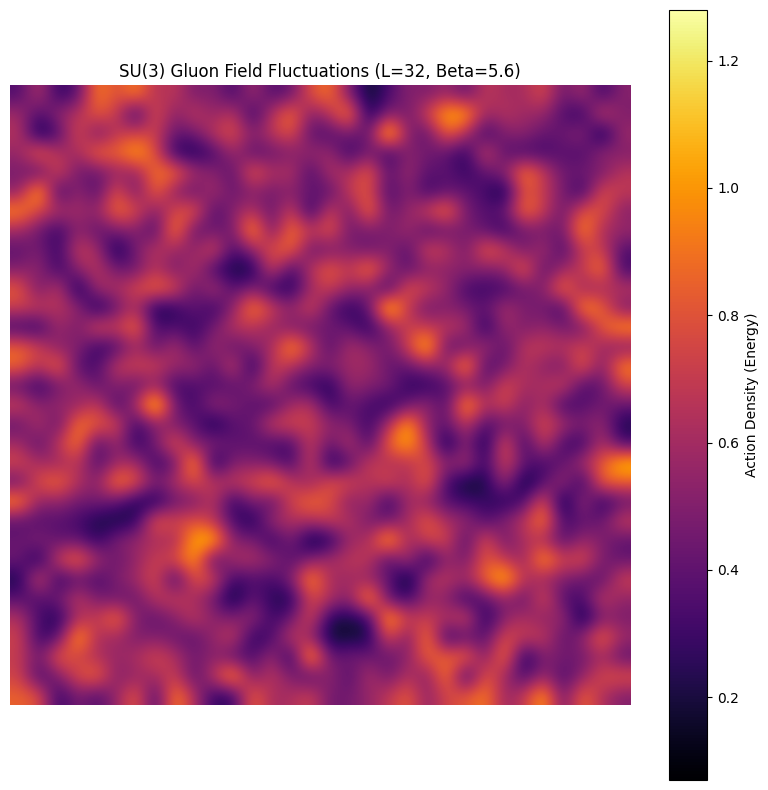

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
L = 32                # Lattice size
B = 1                 # Batch size
BETA = 5.6            # Coupling
N_ITER = 30           # Fast run for visualization
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Visualizer Active: {torch.cuda.get_device_name(0)}")

def init_gauge_field(batch, L, device):
    shape = (batch, 4, L, L, L, L, 3, 3)
    U = torch.eye(3, dtype=torch.complex128, device=device)
    return U.view(1, 1, 1, 1, 1, 1, 3, 3).expand(*shape).clone()

def compute_spatial_plaquettes_2d(U, slice_idx):
    """
    Computes the Action Density (Plaquette value) for a 2D slice of the lattice.
    We look at the X-Y plane (mu=1, nu=2) at a fixed Z and T.
    """
    # U has shape (B, Dir, X, Y, Z, T, 3, 3)
    # We take mu=1 (X), nu=2 (Y)
    # We slice at Z=slice_idx, T=slice_idx

    # Extract 2D planes
    # U_x(x,y)
    Ux = U[:, 1, :, :, slice_idx, slice_idx]
    # U_y(x,y)
    Uy = U[:, 2, :, :, slice_idx, slice_idx]

    # Shifts in 2D (X is dim 1, Y is dim 2 in the extracted tensor?
    # Original: (B, Dir, X, Y, Z, T, 3, 3).
    # Sliced: (B, X, Y, 3, 3) -> Dim 1 is X, Dim 2 is Y.

    # Shift Ux in Y direction (dim 2)
    Ux_shift_y = torch.roll(Ux, shifts=-1, dims=2)
    # Shift Uy in X direction (dim 1)
    Uy_shift_x = torch.roll(Uy, shifts=-1, dims=1)

    # P = Ux * Uy_shift_x * Ux_shift_y.dag * Uy.dag
    P = torch.matmul(Ux, Uy_shift_x)
    P = torch.matmul(P, Ux_shift_y.mH)
    P = torch.matmul(P, Uy.mH)

    # Trace and Real part
    # Density = 1 - (1/3)ReTr(P).  (0 = Order, 1 = Disorder/Energy)
    trace = torch.real(torch.einsum('bxyii->bxy', P))
    density = 1.0 - (trace / 3.0)

    return density[0].cpu().numpy() # Return numpy array for plotting

def update_field(U, beta, epsilon):
    # Simplified update for speed
    for mu in range(4):
        # Calculate random update M
        H = torch.randn(U[:, mu].shape, dtype=torch.complex128, device=U.device)
        H = H - H.mH
        tr = torch.einsum('...ii->...', H).unsqueeze(-1).unsqueeze(-1)
        H = H - tr/3 * torch.eye(3, device=U.device)
        M = torch.matrix_exp(epsilon * H)

        # Blind update (Hot start) or Metropolis?
        # Let's do a quick Metropolis to get real texture
        U_new = torch.matmul(M, U[:, mu])

        # Calculate Staples (Expensive part, inlined for speed)
        staple_sum = torch.zeros_like(U[:, mu])
        for nu in range(4):
            if mu == nu: continue
            U_nu = U[:, nu]
            S_up = torch.matmul(torch.roll(U_nu, -1, dims=mu+1), torch.roll(U[:, mu], -1, dims=nu+1).mH)
            S_up = torch.matmul(S_up, U_nu.mH)

            U_nu_m = torch.roll(U_nu, 1, dims=nu+1)
            S_dn = torch.matmul(U_nu_m.mH, torch.roll(U[:, mu], 1, dims=nu+1))
            S_dn = torch.matmul(S_dn, torch.roll(torch.roll(U_nu, -1, dims=mu+1), 1, dims=nu+1))
            staple_sum += S_up + S_dn

        old_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U[:, mu], staple_sum.mH)))
        new_act = torch.real(torch.einsum('b...ii->b...', torch.matmul(U_new, staple_sum.mH)))

        prob = torch.exp((beta/3.0) * (new_act - old_act))
        mask = torch.rand_like(prob) < prob
        mask_exp = mask.unsqueeze(-1).unsqueeze(-1).expand_as(U_new)
        U[:, mu] = torch.where(mask_exp, U_new, U[:, mu])

    return U

# --- Execution ---
U = init_gauge_field(B, L, DEVICE)
print("--- Generating Quantum Vacuum Texture ---")

# Burn in to get structure
for i in range(N_ITER):
    U = update_field(U, BETA, 0.1)
    if (i+1) % 5 == 0:
        print(f"Iter {i+1}/{N_ITER}...")

# Snapshot
print("--- Capturing Slice ---")
density_map = compute_spatial_plaquettes_2d(U, L//2)

# Plotting
plt.figure(figsize=(10, 10))
plt.imshow(density_map, cmap='inferno', interpolation='bicubic')
plt.colorbar(label="Action Density (Energy)")
plt.title(f"SU(3) Gluon Field Fluctuations (L={L}, Beta={BETA})")
plt.axis('off')

filename = "gluon_field.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ Image Saved: {filename}")
print("Check your file browser to see the structure of the strong force!")